# Local Housing Price Nowcasting
## Econ 148 — Group Project

We build a monthly **nowcast** of local house-price changes for three
structurally different U.S. metros — **San Francisco, Austin, Cleveland** —
and test whether non-linear models (XGBoost, a 2-layer MLP) extract signal
beyond classical linear / time-series baselines (OLS, ARIMA).

**Target.** Monthly log return of the Zillow Home Value Index:
$$y_t \;=\; \ln\!\left(\frac{\text{ZHVI}_t}{\text{ZHVI}_{t-1}}\right).$$
Using log returns instead of raw prices ensures the target is stationary and comparable across metros with vastly different price levels.

**Data sources.**
| Series | Source | Frequency | Purpose |
|---|---|---|---|
| ZHVI, new listings, days-to-pending, price cuts | Zillow Research | Monthly (metro) | Captures local housing market dynamics |
| 30-yr mortgage rate, UNRATE, CPI, housing starts, STLFSI | FRED | Weekly / monthly | Provides national macroeconomic context |
| Metro-level unemployment (LAUS, SA) | FRED | Monthly (metro) | Captures local labor market health |
| Median income, median home value, vacancy rate | Census ACS 5-yr 2024 | One snapshot | Added as a per-metro fixed effect element to absorb structural differences |

**Design choices.**
- The 2024 ACS is a single cross-section, so it functions as a **per-metro
  fixed effect / structural bias**, not a time-varying covariate. Because it
  enters the model as a constant per city and not as a time-varying predictor,
  it cannot leak information across the train/test boundary.
- Leading indicators are **lagged one month** so the model uses information
  that was actually available at nowcast time.
- A single chronological split (**train ≤ 2022-12**, **test 2023-01 →
  latest**) means the test window covers the 2023+ rate-shock regime — a
  genuine out-of-distribution stress test.

## 0. Setup

This cell load all the tools and libraries the notebook need to run and sets up the folder paths.

Libraries :
  - `numpy` and `pandas` support numerical operations and data manipulation
  - `pandas_datareader` collects live data from the FRED API
  - `statsmodels` handles OLS regression and ARIMA
  - `matplotlib` support all the visualization
  - `xgboost` and `sklearn` execute linear models
  - `shap` compute feature attributions

Reproducibility : to ensure full Run All we set `SEED = 0` and pass it to every operations so all bit are identical reproduced accross machines and sessions.

Path :
  - `ROOT` resolves to the repository root regardless of the working directory.
  - `RAW` points to "/data/raw/' for inputs datasets.
  - `OUT_FIG` and `OUT_TAB` points to "outputs/tables/" for all saved results.

Study design :
  - `METROS` matches each city name with its FRED LAUS unemployment serie ID and its Census ACS region label.
  - `TEST_START` and `TRAIN_END` defines the time focus : from December 2022 to January 2023.


In [1]:
!pip install -q pandas_datareader shap xgboost scikit-learn statsmodels

In [2]:
import os, subprocess, sys

# Only clone & chdir on Colab. Locally, run from the repo root and leave cwd alone.
if "google.colab" in sys.modules:
    if not os.path.exists("ECON-148"):
        subprocess.run(["git", "clone", "https://github.com/garavels/ECON-148.git"])
    os.chdir("ECON-148")


In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from pandas_datareader import data as pdr

import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

import xgboost as xgb
import shap

from sklearn.compose import TransformedTargetRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

SEED = 0
np.random.seed(SEED)

ROOT = Path().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
RAW = ROOT / "data" / "raw"
OUT_FIG = ROOT / "outputs" / "figures"; OUT_FIG.mkdir(parents=True, exist_ok=True)
OUT_TAB = ROOT / "outputs" / "tables";  OUT_TAB.mkdir(parents=True, exist_ok=True)

# --- Targets of analysis ------------------------------------------------
METROS = {
    "San Francisco, CA": {"laus": "SANF806URN", "acs": "San Francisco-Oakland-Fremont"},
    "Austin, TX":        {"laus": "AUST448URN", "acs": "Austin-Round Rock"},
    "Cleveland, OH":     {"laus": "CLEV439URN", "acs": "Cleveland, OH Metro Area"},
}
METRO_NAMES = list(METROS)

START, END = "2000-01-01", "2026-03-31"
TRAIN_END, TEST_START = "2022-12-31", "2023-01-01"


## 1. Load raw data

The raw inputs live in `data/raw/`. For series that also have a FRED API
endpoint (the macro series and metro LAUS unemployment), we prefer a live
`pandas_datareader` pull so the notebook stays up-to-date without manual
re-downloads.


### 1.1 Zillow metro panel

Zillow publishes monthly CSVs in **wide** format CVs : one row per city, one column per month.
We reshape each one to **long** format (one row per city per mont)  with `melt`. We also convert the date columns to month-end timestamps, and join the four metro-level series together.

Four different series are loaded here :
  - `zhvi` : Zillow Home Value Index - seasonaly adujsted median home value index.
  - `new_listing` : reports the count of newly listed homes in each months.
  - `days_pending` : measure of market pace based on the median number of days from listing to pending sale.
  - `price_cuts` : measure of seller pressure based on the share of active listing with a price reduction.


In [4]:
ZILLOW_FILES = {
    "zhvi":         "Metro_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv",
    "new_listings": "Metro_new_listings_uc_sfrcondo_sm_month.csv",
    "days_pending": "Metro_med_doz_pending_uc_sfrcondo_sm_month.csv",
    "price_cuts":   "Metro_perc_listings_price_cut_uc_sfrcondo_sm_month.csv",
}
ID_COLS = ["RegionID", "SizeRank", "RegionName", "RegionType", "StateName"]

zillow_frames = []
for key, filename in ZILLOW_FILES.items():
    df = pd.read_csv(RAW / filename)
    date_cols = [c for c in df.columns if c.startswith(("19", "20"))]
    df = df[df["RegionName"].isin(METRO_NAMES)]

    long_df = df.melt(id_vars=ID_COLS, value_vars=date_cols,
                      var_name="date", value_name=key)
    long_df["date"] = pd.to_datetime(long_df["date"]).dt.to_period("M").dt.to_timestamp("M")
    long_df = long_df.rename(columns={"RegionName": "metro"})[["metro", "date", key]]
    zillow_frames.append(long_df)

zillow = zillow_frames[0]
for df in zillow_frames[1:]:
    zillow = zillow.merge(df, on=["metro", "date"], how="outer")

zillow = zillow.sort_values(["metro", "date"]).reset_index(drop=True)
print(f"Zillow panel: {zillow.shape[0]:,} rows  ×  {zillow.shape[1]} cols")
zillow.tail(4)


Zillow panel: 945 rows  ×  6 cols


,metro,date,zhvi,new_listings,days_pending,price_cuts
941,"San Francisco, CA",2025-12-31,"1,136,832.2679","1,766.0000",29.0000,0.1711
942,"San Francisco, CA",2026-01-31,"1,139,902.4047","1,580.0000",28.0000,0.1468
943,"San Francisco, CA",2026-02-28,"1,142,085.7317","2,022.0000",24.0000,0.1348
944,"San Francisco, CA",2026-03-31,"1,143,246.4124","2,987.0000",15.0000,0.1483


We check the earliest non-null observation date for each variable and each metro as a sanity check. We use the index.get_level_values method (https://pandas.pydata.org/docs/reference/api/pandas.Index.get_level_values.html).

In [5]:
def get_first_date(series):
    """Returns the minimum date for non-null values in a series."""
    return series[series].index.get_level_values("date").min() #we do series[series] for filtering


coverage = (
    zillow.set_index(["metro", "date"])
          .notna() # notna() is the opposite fo isna() and is used as a boolean mask here
          .groupby("metro")
          .apply(lambda g: g.apply(get_first_date))
)


### Plot — ZHVI trajectories

We plot a chart to illustrate ZHVI price level trajectories by Metro. Due to the divergent dynamics of each city, we can use a single pooled model on a shared axis. Each city trajectory is illustrated by a different line. The y-axis is formatted in thousands of dollars. This figure is saved to outputs/figures/zhvi_levels.png.

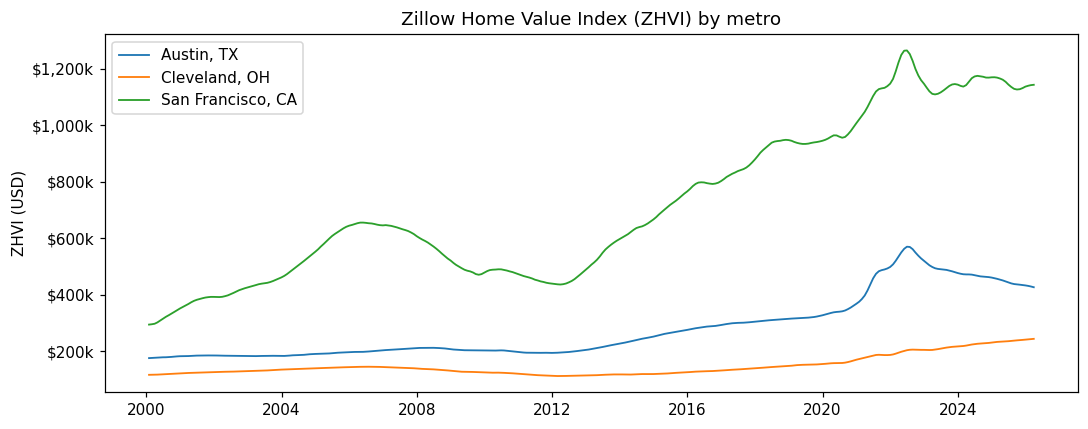

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
for metro, g in zillow.groupby("metro"):
    ax.plot(g["date"], g["zhvi"], label=metro, lw=1.2)

ax.set_title("Zillow Home Value Index (ZHVI) by metro")
ax.set_ylabel("ZHVI (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v/1000:,.0f}k")) # Formats y-axis labels as thousands of dollars (e.g., $1,000k)
ax.legend()

fig.tight_layout() # Adjusts subplot parameters to prevent overlapping elements
fig.savefig(OUT_FIG / "zhvi_levels.png", dpi=150) # dpi=150 sets the resolution of the saved figure to 150 dots per inch
plt.show()


### 1.2 FRED national macro series

We retrieve five national series from FRED. We will not need the API in this case by using`pandas_datareader` (https://pydata.github.io/pandas-datareader/):
  - `MORTGAGE30US` - 30-year fixed mortgage rate.
  - `UNRATE` - Monthly and seasonally adjusted national unemployment rate.
  - `CPIAUCSL` - Monthly urban consumers price index.
  - `HOUST` - monthly new privately-owned housing units started (thousands)
  - `STLFI4` - St. Louis Fed Financial Stress Index.

We resample weekly series (`MORTGAGE30US`, `STLFSI4`) to mont-end means to align with the Zillow and LAUS monthly timeline.

We will define a custom `fetch_fred()` in this case just to make sure that if the live API call fails, we will fall back to the CSVs downloaded in `data/raw/` to ensure full offline reproducibility.

In [7]:
FRED_SERIES = ["MORTGAGE30US", "UNRATE", "CPIAUCSL", "HOUST", "STLFSI4"]
FRED_CSV = {
    "MORTGAGE30US": "MORTGAGE30US.csv", "UNRATE": "UNRATE.csv",
    "CPIAUCSL": "CPIAUCSL.csv",       "HOUST":  "HOUST.csv",
    "STLFSI4":  "STLFSI4.csv",
}


def fetch_fred(series: str) -> pd.Series:
    try:
        return pdr.DataReader(series, "fred", START, END)[series]
    except Exception as e:
        print(f"  [{series}] API failed, using CSV fallback")
        df = pd.read_csv(RAW / FRED_CSV[series], parse_dates=["observation_date"])
        return pd.to_numeric(df[series], errors="coerce").set_axis(df["observation_date"])

We use the resample method (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.resample.html) to ensure monthly consistency.

In [8]:
processed_series = {}

for ticker in FRED_SERIES:
    # we fetch the raw data for this specific ticker and convert to monthly frequency using the mean of that month
    raw_data = fetch_fred(ticker)
    monthly_avg = raw_data.resample("ME").mean()

    # 4. Save it to our dictionary using the ticker as the label
    processed_series[ticker] = monthly_avg

# 5. Combine all individual series into a single horizontal table (DataFrame)
fred_monthly = pd.concat(processed_series, axis=1)


fred_monthly.index.name = "date" # we change the index name

fred_monthly.tail(5)


,MORTGAGE30US,UNRATE,CPIAUCSL,HOUST,STLFSI4
date,,,,,
2025-11-30,6.2375,4.5000,325.0630,"1,324.0000",-0.3377
2025-12-31,6.1900,4.4000,326.0310,"1,373.0000",-0.4254
2026-01-31,6.1025,4.3000,326.5880,"1,398.0000",-0.6525
2026-02-28,6.0475,4.4000,327.4600,"1,356.0000",-0.5511
2026-03-31,6.1775,4.3000,330.2930,"1,502.0000",-0.3176


### Plot — National Macroeconomic Context

We plot a five-panel vertically stacked layout chart to highlight the economic backdrop against which our owcasting models are trained and tested.

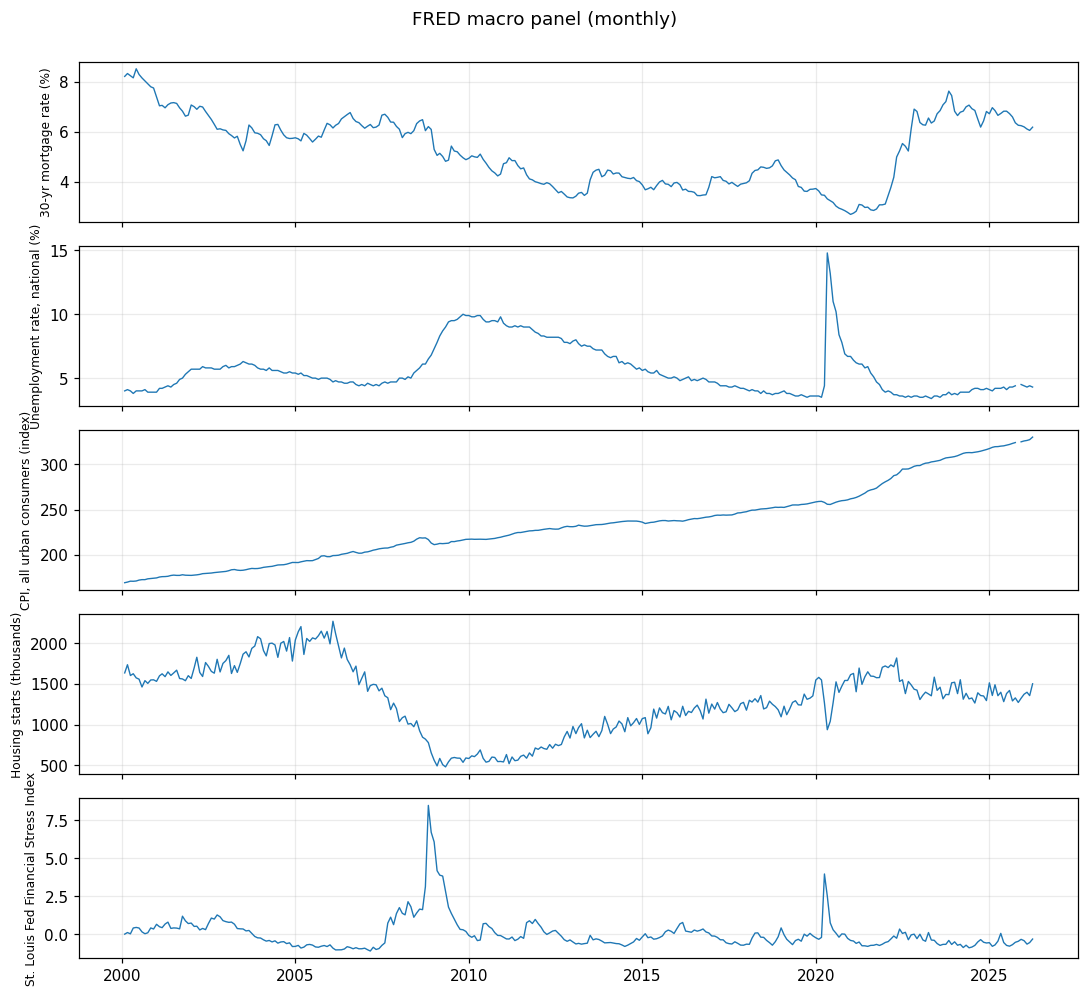

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(10, 9), sharex=True)
series_info = [
    ("MORTGAGE30US", "30-yr mortgage rate (%)"),
    ("UNRATE",       "Unemployment rate, national (%)"),
    ("CPIAUCSL",     "CPI, all urban consumers (index)"),
    ("HOUST",        "Housing starts (thousands)"),
    ("STLFSI4",      "St. Louis Fed Financial Stress Index"),
]

for ax, (col, label) in zip(axes, series_info):
    ax.plot(fred_monthly.index, fred_monthly[col], lw=0.9)
    ax.set_ylabel(label, fontsize=8)
    ax.grid(alpha=0.25)
axes[-1].xaxis.set_major_locator(mdates.YearLocator(5)) # only the last figure has the (shared) index, we put a year mark every 5 years

fig.suptitle("FRED macro panel (monthly)", y=1.00)
fig.tight_layout()
fig.savefig(OUT_FIG / "fred_macro.png", dpi=150)
plt.show()


### 1.3 Metro-level unemployment (LAUS)

National UNRATE applies equally to all three metros which prevent us from distinguishing local dynamics.
In this cell, we pull a separate unemployment series for each metro from FRED using LAUS : the **metro-level** Local Area Unemployment Statistics (LAUS) series.


In [10]:
metro_unrate_frames = []
for metro, meta in METROS.items():
    s = pdr.DataReader(meta["laus"], "fred", START, END)[meta["laus"]]
    metro_unrate_frames.append(
        pd.DataFrame({
            "metro": metro,
            "date": s.index.to_period("M").to_timestamp("M"),
            "unrate_metro": s.values,
        })
    )

metro_unrate = pd.concat(metro_unrate_frames, ignore_index=True)
metro_unrate.groupby("metro")["unrate_metro"].describe()


,count,mean,std,min,25%,50%,75%,max
metro,,,,,,,,
"Austin, TX",313.0000,4.4997,1.4847,2.4000,3.4000,4.0000,5.5000,11.5000
"Cleveland, OH",300.0000,5.5710,1.9096,2.1000,4.5000,5.3000,6.3250,20.6000
"San Francisco, CA",313.0000,5.3674,2.2488,2.3000,3.8000,4.6000,6.4000,13.9000


In [11]:
metro_unrate.tail()

,metro,date,unrate_metro
923,"Cleveland, OH",2024-08-31,3.9000
924,"Cleveland, OH",2024-09-30,3.5000
925,"Cleveland, OH",2024-10-31,2.7000
926,"Cleveland, OH",2024-11-30,3.0000
927,"Cleveland, OH",2024-12-31,3.4000


### Plot - Metro vs National Unemployment Plot

We plot the three metro-level LAUS series alongside the national UNRATE (dashed black line) on a shared axis. The figure is saved to outputs/figures/unrate_metro.png.

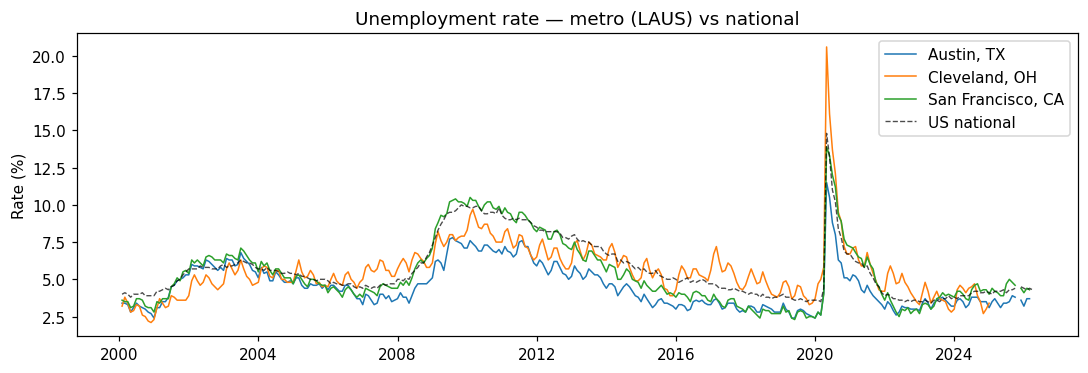

In [12]:
fig, ax = plt.subplots(figsize=(10, 3.5))

for metro, g in metro_unrate.groupby("metro"):
    ax.plot(g["date"], g["unrate_metro"], label=metro, lw=1.0)

ax.plot(fred_monthly.index, fred_monthly["UNRATE"],
        label="US national", color="black", ls="--", lw=0.9, alpha=0.7)
ax.set_title("Unemployment rate — metro (LAUS) vs national")
ax.set_ylabel("Rate (%)")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_FIG / "unrate_metro.png", dpi=150)
plt.show()


### 1.4 Census ACS static features (2024)

The 2024 ACS is a single snapshot, so its three variables below enter the model as **per-metro fixed effects** .
It takes 5 years of survey responses (for the 2024 release, this is data collected from 2019 through 2023). (https://www.census.gov/programs-surveys/acs.html)

We read three ACS tables from CSV and extracts one value per metro for each variable. The three variables extracted are :
  - `acs_median_income` from table S1901.
  - `acs_median_home_value` from table B25077.
  - `acs_vacancy_rate` from table DP04.

| Variable | ACS table | Role |
|---|---|---|
| Median household income | S1901 | Proxy for purchasing power |
| Median home value | B25077 | Price level anchor |
| Vacancy rate (%) | DP04 | Supply slack |

In [13]:
import re
import numpy as np

def load_acs_file(raw_dir, prefix):
    """
    Load the most recent ACS CSV matching the given table prefix.
    Handles Census download timestamps in filenames, e.g.:
        ACSDP5Y2024.DP04-2026-04-20T011849.csv
    """
    candidates = sorted(raw_dir.glob(f"{prefix}*.csv"))
    if not candidates:
        raise FileNotFoundError(
            f"No ACS file matching prefix '{prefix}' found in {raw_dir}"
        )
    chosen = candidates[-1]
    print(f"  Loading ACS file: {chosen.name}")
    return pd.read_csv(chosen)

s1901  = load_acs_file(RAW, "ACSST5Y2024.S1901")
b25077 = load_acs_file(RAW, "ACSDT5Y2024.B25077")
dp04   = load_acs_file(RAW, "ACSDP5Y2024.DP04")

acs_rows = []

for metro, meta in METROS.items():

    # we first Extract Median Income (Table S1901) ---
    inc_col = next((c for c in s1901.columns if meta["acs"] in c and c.endswith("Households!!Estimate")), None)     # Find the specific column for this metro that ends with 'Households!!Estimate'
    label_col = s1901.columns[0] # The first column contains the row labels
    hit_inc = s1901[s1901[label_col].astype(str).str.contains("Median income", na=False)] # Find the row where the label contains "Median income"

    inc_val = np.nan

    if not hit_inc.empty and inc_col:
        # we remove everything EXCEPT digits, dots, and minus signs (strips $, commas, etc.)
        s = re.sub(r"[^\d.\-]", "", str(hit_inc.iloc[0][inc_col]))
        if s and s not in {"-", "(X)", "N", ""}: # Ensure we didn't just get a blank string or a Census placeholder like "(X)"
            inc_val = float(s)

    # we Extract Median Home Value (Table B25077) ---
    val_col = next((c for c in b25077.columns if meta["acs"] in c and c.endswith("Estimate")), None)
    label_col = b25077.columns[0]
    hit_val = b25077[b25077[label_col].astype(str).str.contains("Median value", na=False)]
    home_val = np.nan
    if not hit_val.empty and val_col:
        s = re.sub(r"[^\d.\-]", "", str(hit_val.iloc[0][val_col]))
        if s and s not in {"-", "(X)", "N", ""}:
            home_val = float(s)

    # we Extract Vacancy Rate (Table DP04) ---
    # find the column for this metro ending in 'Percent'
    vac_col = next((c for c in dp04.columns if meta["acs"] in c and c.endswith("Percent")), None)
    label_col = dp04.columns[0]
    hit_vac = dp04[dp04[label_col].astype(str).str.contains("Vacant housing units", na=False)]
    vac_val = np.nan
    if not hit_vac.empty and vac_col:
        s = re.sub(r"[^\d.\-]", "", str(hit_vac.iloc[0][vac_col]))
        if s and s not in {"-", "(X)", "N", ""}:
            vac_val = float(s)

    # store the cleaned results for this metro
    acs_rows.append({
        "metro": metro,
        "acs_median_income": inc_val,
        "acs_median_home_value": home_val,
        "acs_vacancy_rate": vac_val
    })

# convert the list of dictionaries into a clean, analysis-ready DataFrame
acs = pd.DataFrame(acs_rows)
acs


  Loading ACS file: ACSST5Y2024.S1901-2026-04-20T012535.csv
  Loading ACS file: ACSDT5Y2024.B25077-2026-04-20T011959.csv
  Loading ACS file: ACSDP5Y2024.DP04-2026-04-20T011849.csv


,metro,acs_median_income,acs_median_home_value,acs_vacancy_rate
0,"San Francisco, CA","108,092.0000","1,140,700.0000",7.2000
1,"Austin, TX","100,431.0000","465,000.0000",5.1000
2,"Cleveland, OH","40,801.0000","102,000.0000",15.6000


### 1.5 Assembling the final dataset

We merge all four data source into a single-long format dataframe indexed by metro x date. We join it in the following order :
1. Zillow metro panel (`metro × date`) : base table
2. FRED national macro (`date` only) : left join on date, broadcasted across metros
3. join metro LAUS (keyed on `metro × date`) : left join on both keys
4. join ACS static features (keyed on `metro` only) : left join on metro and repeated across all months.

Rows are sorted by metro then date and the index is reset.

In [14]:
fred_long = fred_monthly.reset_index().assign(
    date=lambda d: pd.to_datetime(d["date"]).dt.to_period("M").dt.to_timestamp("M")
)

panel = (
    zillow
    .merge(fred_long, on="date", how="left")
    .merge(metro_unrate, on=["metro", "date"], how="left")
    .merge(acs, on="metro", how="left")
    .sort_values(["metro", "date"])
    .reset_index(drop=True)
)


panel.head(3)


,metro,date,zhvi,new_listings,days_pending,price_cuts,MORTGAGE30US,UNRATE,CPIAUCSL,HOUST,STLFSI4,unrate_metro,acs_median_income,acs_median_home_value,acs_vacancy_rate
0,"Austin, TX",2000-01-31,"176,345.2543",NaN,NaN,NaN,8.2100,4.0000,169.3000,"1,636.0000",0.0061,3.4000,"100,431.0000","465,000.0000",5.1000
1,"Austin, TX",2000-02-29,"176,925.1289",NaN,NaN,NaN,8.3250,4.1000,170.0000,"1,737.0000",0.1112,3.4000,"100,431.0000","465,000.0000",5.1000
2,"Austin, TX",2000-03-31,"177,456.0825",NaN,NaN,NaN,8.2400,4.0000,171.0000,"1,604.0000",0.0247,3.3000,"100,431.0000","465,000.0000",5.1000


### Plot — missingness heatmap

We visualize missingness before any modelling step makes the 2018 Zillow
listings boundary obvious and prevents us from being surprised later when
training rows evaporate.
We compute the share of missing values per column per year and displays the result as a heatmap. Dark cells indicate full data, light cells means that missing data are present. The figure is saved to outputs/figures/missingness.png.


In [15]:
missing = (
    panel
    .assign(year=panel["date"].dt.year)
    .groupby("year")
    .apply(lambda g: g.drop(columns=["metro", "date", "year"]).isna().mean())
)

missing.head()

,zhvi,new_listings,days_pending,price_cuts,MORTGAGE30US,UNRATE,CPIAUCSL,HOUST,STLFSI4,unrate_metro,acs_median_income,acs_median_home_value,acs_vacancy_rate
year,,,,,,,,,,,,,
2000,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2001,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2002,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2003,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2004,0.0000,1.0000,1.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


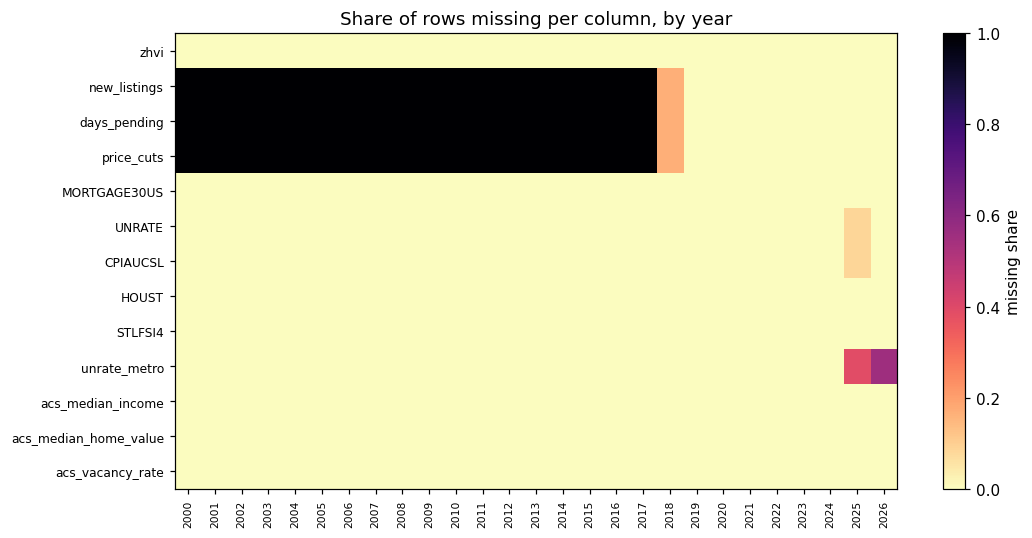

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
im = ax.imshow(missing.T, aspect="auto", cmap="magma_r", vmin=0, vmax=1)
ax.set_yticks(range(len(missing.columns)))
ax.set_yticklabels(missing.columns, fontsize=8)
ax.set_xticks(range(len(missing.index)))
ax.set_xticklabels(missing.index, rotation=90, fontsize=7)
ax.set_title("Share of rows missing per column, by year")
fig.colorbar(im, ax=ax, label="missing share")
fig.tight_layout()
fig.savefig(OUT_FIG / "missingness.png", dpi=150)
plt.show()

### 1.6 Summary Statistics

We compute descriptive statistics for all key variables, grouped by metropolitan area.
This table reports count, mean, standard deviation, minimum, quartiles and maximum
for each numeric series in the final panel. It is saved automatically to
`outputs/tables/summary_statistics.csv`.

In [43]:
SUMMARY_COLS = [
    "zhvi",
    "y_logret",
    "MORTGAGE30US",
    "UNRATE",
    "unrate_metro",
    "CPIAUCSL",
    "HOUST",
    "STLFSI4",
    "new_listings",
    "days_pending",
    "price_cuts",
    "acs_median_income",
    "acs_median_home_value",
    "acs_vacancy_rate",
]

def compute_summary(df, cols):
    return df.groupby("metro")[cols].describe().round(4)

def save_summary(summary, path):
    summary.to_csv(path)
    return summary

def build_and_save_summary(df, cols, path):
    summary = compute_summary(df, cols)
    return save_summary(summary, path)

summary_stats = build_and_save_summary(
    panel,
    SUMMARY_COLS,
    OUT_TAB / "summary_statistics.csv"
)

summary_stats

import subprocess

def push_outputs():
    cmds = [
        "git -C /content/ECON-148 add outputs/tables/summary_statistics.csv",
        "git -C /content/ECON-148 commit -m 'auto: save summary statistics'",
        "git -C /content/ECON-148 push"
    ]
    for cmd in cmds:
        subprocess.run(cmd.split(), capture_output=True)

push_outputs()

## 2. Feature engineering

We now have to deal with **ZHVI in dollars being non-stationary**
(it drifts upward for decades), and lagging matters for economic causality.
We produce a modelling frame by:

| # | Transform | Rationale |
|---|---|---|
| 2.1 | ZHVI → log return | stationary target |
| 2.2 | First-difference rate-like series | removes unit roots |
| 2.3 | Log levels for strictly positive stock series | variance stabilisation |
| 2.4 | YoY log change for CPI | inflation as a rate |
| 2.5 | `shift(1)` on leading indicators | respect information timing |
| 2.6 | One-hot `metro` | cross-sectional fixed effect |


### 2.1 Target Variable : Monthly Log Return of ZHVI

We compute the log return of ZHVI within each city group using a grouped transform and numpy's diff on log values :

$$y_t = \ln(\text{ZHVI}_t / \text{ZHVI}_{t-1})$$

Using a log *return* rather than the raw price change means the target has
a stable mean and variance across metros with very different price levels
(Cleveland ~$100k, SF ~$1.1M).

The result is stored as `y_logret` in the dataframe.

The chart plots the series for each city on separate panels but with a shared x-axis.
The red dash line marks the train/test boundary at January 2023. The figure is
saved to outputs/figures/target_logret.png.

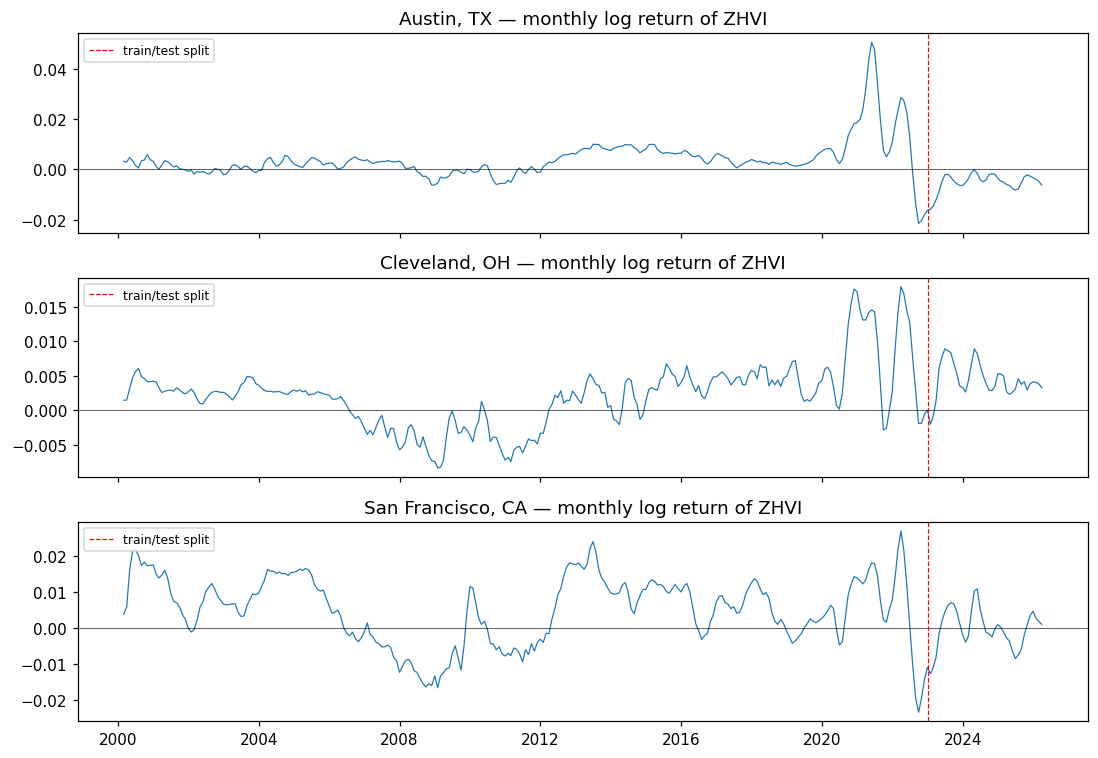

In [17]:
panel["y_logret"] = (
    panel.sort_values(["metro", "date"])
         .groupby("metro")["zhvi"]
         .transform(lambda s: np.log(s).diff())
)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, (metro, g) in zip(axes, panel.groupby("metro")):
    ax.plot(g["date"], g["y_logret"], lw=0.8)
    ax.axhline(0, color="k", lw=0.4)
    ax.axvline(pd.Timestamp(TEST_START), color="red", ls="--", lw=0.8,
               label="train/test split")
    ax.set_title(f"{metro} — monthly log return of ZHVI")
    ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(OUT_FIG / "target_logret.png", dpi=150)
plt.show()


### 2.2–2.4 Stationarity transforms

Stationarity transforms are needed because economic and housing time series (like price levels) exhibit trends or unit roots. Models like OLS, ARIMA, and Neural Networks struggle with non-stationary data. By taking first differences, log levels, or year-over-year changes, we stabilize the mean and variance, making the series stationary and easier to model.


We apply here several transformation to each feature :
  - First difference : `MORTGAGE30US`, `UNRATE`, `unrate_metro` :  **Rates / percentages** - A rate of 7% is not twice as meaningful as 3.5%, but the *change* in rate is what triggers behaviour.
  
  N.B. We don't log cause we care about the absolute diffrence in this case.
  - Log Level : `HOUST`, `new_listings`, `days_pending`
  - year-over-year log change : `CPIAUCSL`
  - `STLFSI4` and `price_cuts` are already bounded / standardised; we keep
  them as levels.


In [18]:
def per_metro_diff(df, col):
    return df.sort_values(["metro", "date"]).groupby("metro")[col].transform("diff")


feat = panel.copy()

# first differences
feat["d_mortgage30"]  = feat["MORTGAGE30US"].diff()
feat["d_unrate_nat"]  = feat["UNRATE"].diff()
feat["d_unrate_metro"] = per_metro_diff(feat, "unrate_metro")

# YoY log inflation
feat["cpi_yoy"] = np.log(feat["CPIAUCSL"]).diff(12) # for Yoy change

# log levels (guarded against zeros) and their per-metro first differences
# the d_log_* versions are the stationary inputs used by the models;
# the log_* levels are kept for plotting / commentary only.
for col in ["HOUST", "new_listings", "days_pending"]:
    log_col = f"log_{col.lower()}"
    feat[log_col] = np.log(feat[col].where(feat[col] > 0))
    feat[f"d_{log_col}"] = per_metro_diff(feat, log_col)


feat["price_cuts"] = feat["price_cuts"]
feat["stlfsi"] = feat["STLFSI4"]

# preview
feat[[
    "metro", "date", "y_logret",
    "d_mortgage30", "d_unrate_nat", "d_unrate_metro", "cpi_yoy",
    "d_log_houst", "d_log_new_listings", "d_log_days_pending",
    "price_cuts", "stlfsi",
]].tail(5)


,metro,date,y_logret,d_mortgage30,d_unrate_nat,d_unrate_metro,cpi_yoy,d_log_houst,d_log_new_listings,d_log_days_pending,price_cuts,stlfsi
940,"San Francisco, CA",2025-11-30,0.0034,-0.0165,NaN,NaN,0.0266,0.0401,-0.1477,0.0488,0.2005,-0.3377
941,"San Francisco, CA",2025-12-31,0.0047,-0.0475,-0.1000,-0.3000,0.0262,0.0363,-0.4367,0.3228,0.1711,-0.4254
942,"San Francisco, CA",2026-01-31,0.0027,-0.0875,-0.1000,0.3000,0.0236,0.0180,-0.1113,-0.0351,0.1468,-0.6525
943,"San Francisco, CA",2026-02-28,0.0019,-0.0550,0.1000,-0.1000,0.0240,-0.0305,0.2467,-0.1542,0.1348,-0.5511
944,"San Francisco, CA",2026-03-31,0.0010,0.1300,-0.1000,NaN,0.0323,0.1023,0.3902,-0.4700,0.1483,-0.3176


### Plot — Before & After Stationarity - Visual Check

We plot the level and transformed version of two series side by side using Austin as teh representative metro. The four-panel display `MORTGAGE30US` and `CPIAUCSL` before and after the transformation.
The figure is saved to outputs/figures/stationarity_check.png.

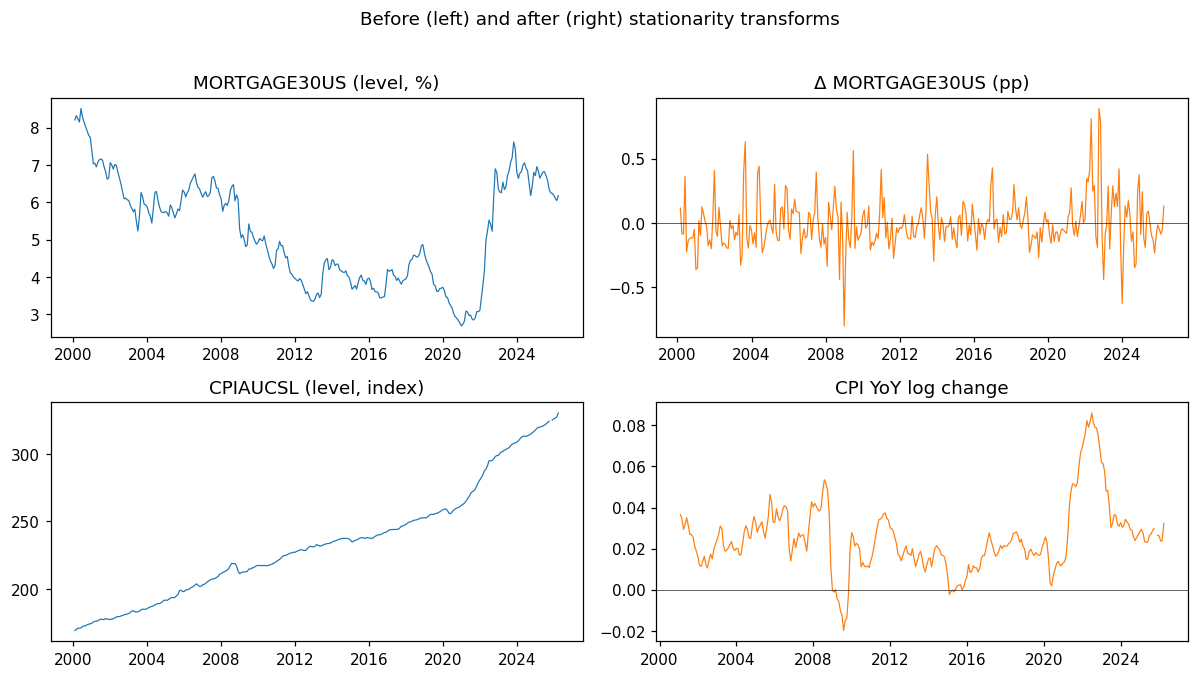

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(11, 6))
dates = feat.query("metro == 'Austin, TX'")["date"]

axes[0,0].plot(dates, feat.query("metro == 'Austin, TX'")["MORTGAGE30US"], lw=0.8)
axes[0,0].set_title("MORTGAGE30US (level, %)")
axes[0,1].plot(dates, feat.query("metro == 'Austin, TX'")["d_mortgage30"], lw=0.8, color="C1")
axes[0,1].axhline(0, color="k", lw=0.4); axes[0,1].set_title("Δ MORTGAGE30US (pp)")

axes[1,0].plot(dates, feat.query("metro == 'Austin, TX'")["CPIAUCSL"], lw=0.8)
axes[1,0].set_title("CPIAUCSL (level, index)")
axes[1,1].plot(dates, feat.query("metro == 'Austin, TX'")["cpi_yoy"], lw=0.8, color="C1")
axes[1,1].axhline(0, color="k", lw=0.4); axes[1,1].set_title("CPI YoY log change")

fig.suptitle("Before (left) and after (right) stationarity transforms", y=1.02)
fig.tight_layout()
fig.savefig(OUT_FIG / "stationarity.png", dpi=150)
plt.show()


### 2.5 Lagging Predictor Variables by One Month

Economic cause and effect do not happen in the same calendar month: a
mortgage-rate hike in January shows up in housing activity in February+.

We apply `shift(1)` within each metro to all exogenous features. (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shift.html)

In [20]:
TARGET = "y_logret"
LAG1_FEATURES = [
    "d_mortgage30", "d_unrate_nat", "d_unrate_metro",
    "d_log_houst", "d_log_new_listings", "d_log_days_pending",
    "price_cuts", "stlfsi",
]
CONTEMP_FEATURES = ["cpi_yoy"]            # inflation regime at time t
STATIC_FEATURES = []  # ACS values are constant per metro; collinear with metro dummies

for col in LAG1_FEATURES:
    feat[col] = (
        feat.sort_values(["metro", "date"])
            .groupby("metro")[col]
            .shift(1)
    )

feat[["metro", "date"] + LAG1_FEATURES].tail(5)


,metro,date,d_mortgage30,d_unrate_nat,d_unrate_metro,d_log_houst,d_log_new_listings,d_log_days_pending,price_cuts,stlfsi
940,"San Francisco, CA",2025-11-30,-0.0985,NaN,NaN,-0.0431,0.0098,-0.0953,0.2147,-0.4663
941,"San Francisco, CA",2025-12-31,-0.0165,NaN,NaN,0.0401,-0.1477,0.0488,0.2005,-0.3377
942,"San Francisco, CA",2026-01-31,-0.0475,-0.1000,-0.3000,0.0363,-0.4367,0.3228,0.1711,-0.4254
943,"San Francisco, CA",2026-02-28,-0.0875,-0.1000,0.3000,0.0180,-0.1113,-0.0351,0.1468,-0.6525
944,"San Francisco, CA",2026-03-31,-0.0550,0.1000,-0.1000,-0.0305,0.2467,-0.1542,0.1348,-0.5511


### 2.6 Metro Fixed Effects and Final Feature Matrix

We apply the `pd.get_dummies()`to the metro column, producing three binary columns prefixed with `metro_`. These are concatenated to the feature dataframe.

In [21]:
metro_dummies = pd.get_dummies(feat["metro"], prefix="metro", dtype=float)
feat = pd.concat([feat, metro_dummies], axis=1)

FEATURES = LAG1_FEATURES + CONTEMP_FEATURES + STATIC_FEATURES + list(metro_dummies.columns)

model_frame = feat[["metro", "date", TARGET] + FEATURES].copy()


print(f"Features ({len(FEATURES)}): {FEATURES}")
model_frame.dropna().head(3)


Features (12): ['d_mortgage30', 'd_unrate_nat', 'd_unrate_metro', 'd_log_houst', 'd_log_new_listings', 'd_log_days_pending', 'price_cuts', 'stlfsi', 'cpi_yoy', 'metro_Austin, TX', 'metro_Cleveland, OH', 'metro_San Francisco, CA']


,metro,date,y_logret,d_mortgage30,d_unrate_nat,d_unrate_metro,d_log_houst,d_log_new_listings,d_log_days_pending,price_cuts,stlfsi,cpi_yoy,"metro_Austin, TX","metro_Cleveland, OH","metro_San Francisco, CA"
220,"Austin, TX",2018-05-31,0.0028,0.0235,0.0000,-0.3000,-0.0324,0.2060,-0.4595,0.1907,0.0901,0.0274,1.0000,0.0000,0.0000
221,"Austin, TX",2018-06-30,0.0020,0.1185,-0.2000,0.0000,0.0615,0.1138,-0.0870,0.2173,-0.1952,0.0277,1.0000,0.0000,0.0000
222,"Austin, TX",2018-07-31,0.0030,-0.0160,0.2000,0.5000,-0.1296,0.0113,0.0870,0.2488,-0.2062,0.0281,1.0000,0.0000,0.0000


### Plot — Feature Correlation Matrix

We cluster features by pairwise Pearson correlation among all numeric features
in `model_frame` and displays the result as an annotated heatmap. Values
above |0.55| are shown in white text. The figure is saved to
outputs/figures/feature_corr.png.

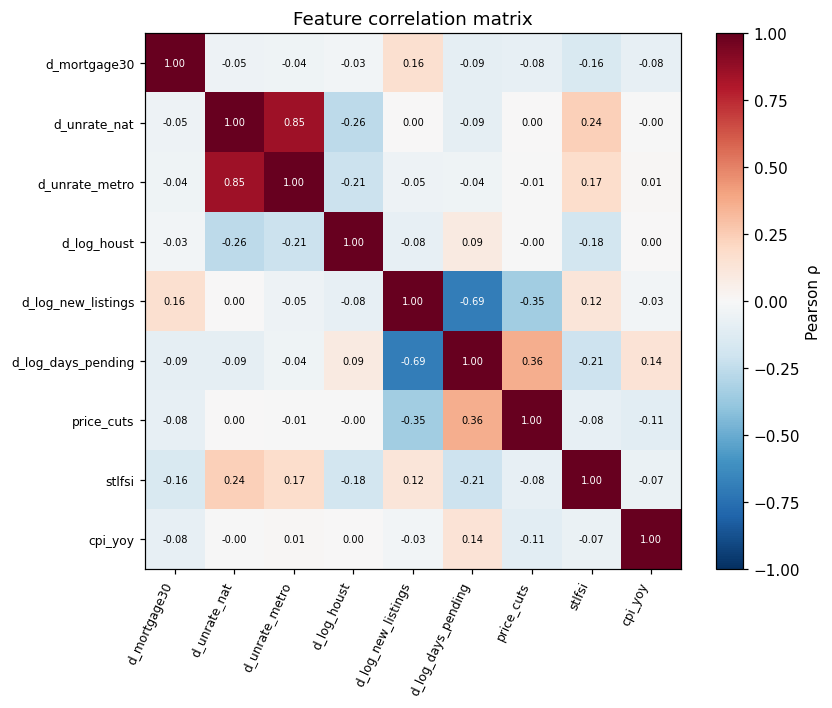

In [22]:
num_feats = [c for c in FEATURES if not c.startswith("metro_")]
corr = model_frame[num_feats].corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(num_feats))); ax.set_xticklabels(num_feats, rotation=65, ha="right", fontsize=8)
ax.set_yticks(range(len(num_feats))); ax.set_yticklabels(num_feats, fontsize=8)
for i in range(len(num_feats)):
    for j in range(len(num_feats)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}",
                ha="center", va="center", fontsize=6.5,
                color="white" if abs(corr.iloc[i, j]) > 0.55 else "black")
fig.colorbar(im, ax=ax, label="Pearson ρ")
ax.set_title("Feature correlation matrix")
fig.tight_layout()
fig.savefig(OUT_FIG / "feature_corr.png", dpi=150)
plt.show()


The correlation matrix confirms that our feature set spans several distinct economic dimensions with limited multicollinearity.

The most notable cluster is between the Zillow listing-side features: `log_new_listings` and `log_days_pending` are negatively correlated — when more homes are on the market, competition between sellers intensifies and homes take fewer days to go pending, a classic inventory-vs-pace dynamic. `log_houst` (national housing starts) correlates positively with `log_new_listings`, reflecting that supply-side expansions show up at both the national construction and metro listing level simultaneously.

The macro series (`d_mortgage30`, `d_unrate_nat`, `cpi_yoy`, `stlfsi`) are largely orthogonal to the Zillow listing-side features. This is reassuring: national credit conditions and local market frictions capture genuinely different dimensions of the housing cycle and will not co-move in the OLS regression in a way that inflates standard errors or destabilises coefficient estimates.

The ACS static features (`acs_median_income`, `acs_median_home_value`, `acs_vacancy_rate`) show near-zero correlation with every time-varying feature — expected, since they are constants within each metro. No pair of non-dummy features reaches |ρ| > 0.7, so multicollinearity is not a structural concern for any of the models.

## 3. Train / test split

We split the dataset.


In [23]:
train = model_frame[model_frame["date"] <= pd.Timestamp(TRAIN_END)].copy()
test  = model_frame[model_frame["date"] >= pd.Timestamp(TEST_START)].copy()

split_tbl = pd.DataFrame({
    "split": ["train", "test"],
    "rows":  [len(train), len(test)],
    "start": [train["date"].min(), test["date"].min()],
    "end":   [train["date"].max(), test["date"].max()],
})
split_tbl


,split,rows,start,end
0,train,828,2000-01-31,2022-12-31
1,test,117,2023-01-31,2026-03-31


We plot the coverage per metro to visualize our train and eval datasets graphically.

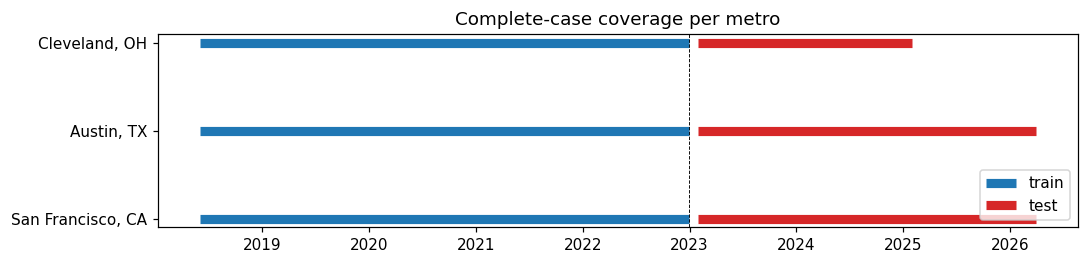

In [24]:
fig, ax = plt.subplots(figsize=(10, 2.5))
for i, metro in enumerate(METRO_NAMES):
    tr = train.query("metro == @metro").dropna(subset=FEATURES + [TARGET])
    te = test.query("metro == @metro").dropna(subset=FEATURES + [TARGET])
    ax.hlines(i, tr["date"].min(), tr["date"].max(), color="C0", lw=6, label="train" if i == 0 else None)
    ax.hlines(i, te["date"].min(), te["date"].max(), color="C3", lw=6, label="test"  if i == 0 else None)
ax.set_yticks(range(len(METRO_NAMES))); ax.set_yticklabels(METRO_NAMES)
ax.axvline(pd.Timestamp(TRAIN_END), color="k", ls="--", lw=0.6)
ax.legend(loc="lower right"); ax.set_title("Complete-case coverage per metro")
fig.tight_layout()
fig.savefig(OUT_FIG / "split_coverage.png", dpi=150)
plt.show()


## 4. ARIMA baseline (univariate, per metro)

ARIMA uses only the target's own past values and forecast errors. It is the benchmark for "how much of the variation is captured by pure price momentum / mean-reversion?". ARIMA can use more months than OLS/XGB because it doesn't depend on the listing-side features that are missing pre-2018.

### Mathematical formulation

An ARIMA model explains $y_t$ using its own history. Since $y_t$ is already approximately stationary, we set $d = 0$, so the model reduces to an ARMA$(p, q)$:

$$
y_t = \mu + \sum_{i=1}^{p} \phi_i y_{t-i} + \varepsilon_t + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}
$$

where $\varepsilon_t$ is a random innovation. The autoregressive terms $\phi_i y_{t-i}$ capture persistence in past returns, while the moving-average terms $\theta_j \varepsilon_{t-j}$ capture dependence on past shocks.

We estimate the parameters by maximum likelihood and choose $(p, q)$ using AIC:

$$
\text{AIC} = -2 \log \hat{\mathcal{L}} + 2k
$$

where smaller AIC is preferred.

  San Francisco, CA: best order = ARIMA(1, 0, 7)  (AIC = -2682.39)
  Austin, TX: best order = ARIMA(4, 0, 9)  (AIC = -2858.41)
  Cleveland, OH: best order = ARIMA(9, 0, 7)  (AIC = -2995.21)


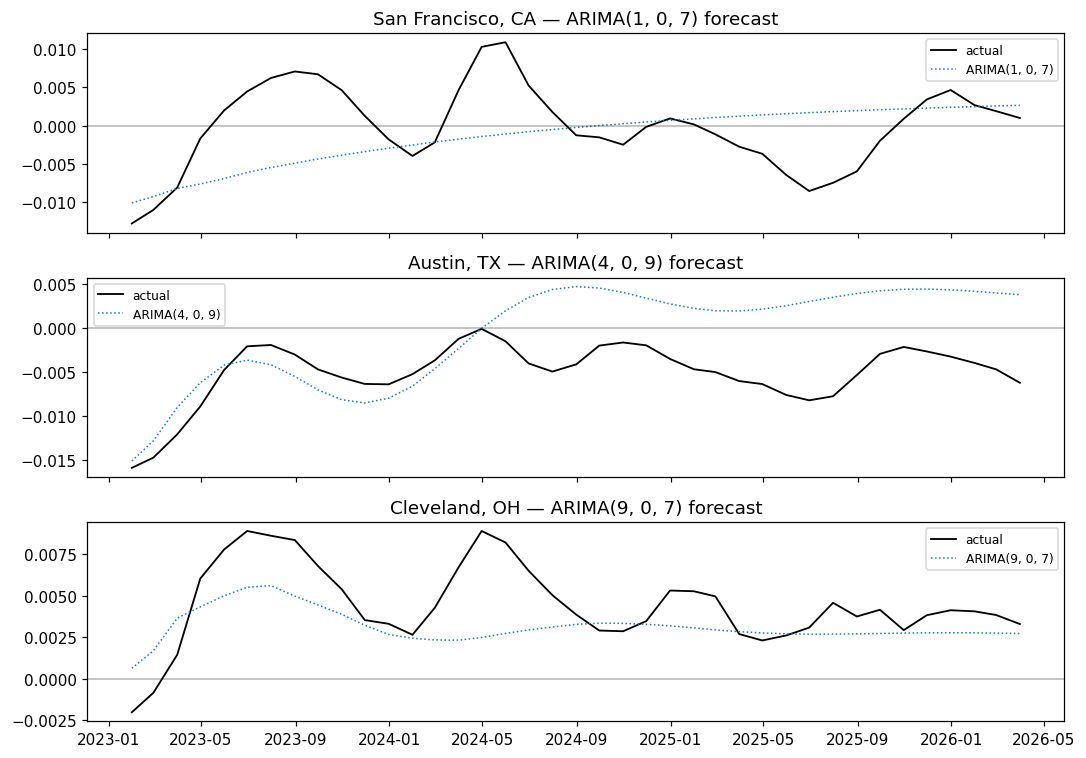

In [25]:
from itertools import product as iterproduct

# --- AIC-based order search per metro (p, q ∈ {0,...,9}, d fixed at 0) ---
best_orders = {}
for metro in METRO_NAMES:
    tr = train.query("metro == @metro").dropna(subset=[TARGET]).sort_values("date")
    best_aic, best_order = np.inf, (1, 0, 1)
    for p, q in iterproduct(range(10), range(10)):
        try:
            aic = ARIMA(tr[TARGET].astype(float).values, order=(p, 0, q)).fit().aic
            if aic < best_aic:
                best_aic, best_order = aic, (p, 0, q)
        except Exception:
            continue
    best_orders[metro] = best_order
    print(f"  {metro}: best order = ARIMA{best_order}  (AIC = {best_aic:.2f})")

# --- Fit with selected orders and forecast ---
arima_preds = []
for metro in METRO_NAMES:
    tr = train.query("metro == @metro").dropna(subset=[TARGET]).sort_values("date")
    te = test.query("metro == @metro").dropna(subset=[TARGET]).sort_values("date")
    arima = ARIMA(tr[TARGET].astype(float).values, order=best_orders[metro]).fit()
    forecast = arima.forecast(steps=len(te))
    arima_preds.append(te[["metro", "date", TARGET]].assign(y_pred_arima=forecast))

arima_preds = pd.concat(arima_preds, ignore_index=True)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, metro in zip(axes, METRO_NAMES):
    g = arima_preds.query("metro == @metro")
    label = f"ARIMA{best_orders[metro]}"
    ax.plot(g["date"], g["y_logret"],     label="actual", lw=1.2, color="black")
    ax.plot(g["date"], g["y_pred_arima"], label=label,    lw=1.0, ls=":")
    ax.axhline(0, color="k", lw=0.3)
    ax.set_title(f"{metro} — {label} forecast"); ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_FIG / "pred_arima.png", dpi=150)
plt.show()

ARIMA outputs a nearly flat line — the model has converged on the
unconditional mean of the training series. That is an honest baseline: any
model that can't beat a flat forecast isn't extracting information from
the exogenous features.

### Stationarity Tests (Augmented Dickey-Fuller)

Before fitting the OLS model we verify that each numeric feature is stationary.
The Augmented Dickey-Fuller (ADF) test checks for the presence of a unit root in
each time-series feature. A **unit root** means the series has a stochastic trend
and is therefore non-stationary.

**Null hypothesis (H0):** The series has a unit root (non-stationary).

**Alternative hypothesis (H1):** The series is stationary.

We reject H0 when p < 0.05, concluding the feature is stationary. Features
flagged as non-stationary should be further differenced, log-transformed, or
removed before OLS fitting to avoid spurious regression.


In [26]:
from statsmodels.tsa.stattools import adfuller

num_feats = [c for c in FEATURES if not c.startswith("metro_")]

# build a NaN-free training slice locally (train_c is defined later in the OLS prep cell)
adf_train = train.dropna(subset=FEATURES + [TARGET])

print("=== Augmented Dickey-Fuller Stationarity Tests ===")
print()
print(f"{'Feature':<25} {'ADF Stat':>10} {'p-value':>10} {'Stationary?':>12}")
print("-" * 60)

for col in num_feats:
    series = adf_train[col].dropna().astype(float)
    if len(series) < 20:
        print(f"{col:<25} {'SKIP':>10} {'N/A':>10} {'too few obs':>12}")
        continue
    result = adfuller(series, autolag="AIC")
    adf_stat, p_val = result[0], result[1]
    is_stationary = "Yes" if p_val < 0.05 else "** NO **"
    print(f"{col:<25} {adf_stat:>10.4f} {p_val:>10.4f} {is_stationary:>12}")


=== Augmented Dickey-Fuller Stationarity Tests ===

Feature                     ADF Stat    p-value  Stationary?
------------------------------------------------------------
d_mortgage30                 -2.7715     0.0625     ** NO **
d_unrate_nat                -10.3283     0.0000          Yes
d_unrate_metro              -13.0871     0.0000          Yes
d_log_houst                  -9.8441     0.0000          Yes
d_log_new_listings           -5.6679     0.0000          Yes
d_log_days_pending           -2.6885     0.0760     ** NO **
price_cuts                   -2.8242     0.0549     ** NO **
stlfsi                       -6.6676     0.0000          Yes
cpi_yoy                      -4.5166     0.0002          Yes


## 5. OLS baseline (pooled, with metro dummies)

A single ordinary-least-squares regression across all three metros. The
metro dummies act as fixed effects; the numeric features have a single
pooled slope per predictor.

In [27]:
train_c = train.dropna(subset=FEATURES + [TARGET])
test_c  = test.dropna(subset=FEATURES + [TARGET])

X_tr = sm.add_constant(train_c[FEATURES].astype(float), has_constant="add")
X_te = sm.add_constant(test_c[FEATURES].astype(float),  has_constant="add")

ols_model = sm.OLS(train_c[TARGET].astype(float), X_tr).fit(
    cov_type="HAC", cov_kwds={"maxlags": 3}
)
print(ols_model.summary())


                            OLS Regression Results                            
Dep. Variable:               y_logret   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.728
Method:                 Least Squares   F-statistic:                     38.29
Date:                Fri, 01 May 2026   Prob (F-statistic):           2.21e-40
Time:                        08:01:17   Log-Likelihood:                 632.73
No. Observations:                 168   AIC:                            -1241.
Df Residuals:                     156   BIC:                            -1204.
Df Model:                          11                                         
Covariance Type:                  HAC                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

The t-statistics tell us the significant drivers *in a linear world*.
Signs should line up with economic intuition: negative on `d_mortgage30`,
negative on `price_cuts` (more cuts = softer market), and so on.

### OLS Residual Diagnostics

After fitting OLS we run standard post-estimation checks to verify
that the model's assumptions hold.

**Durbin-Watson** tests for autocorrelation in the residuals.
Values near 2.0 indicate no significant autocorrelation. Values
well below 2 suggest positive autocorrelation; values well above 2
suggest negative autocorrelation.

**Jarque-Bera** tests whether the residuals follow a normal distribution.
If p < 0.05 we reject the normality assumption, which means confidence
intervals and hypothesis tests derived from OLS may be unreliable.

**Variance Inflation Factor (VIF)** quantifies how much each feature's
coefficient variance is inflated by multicollinearity. A VIF above 10
is a common threshold indicating problematic collinearity; features
exceeding this should be investigated.

**Residuals vs. Fitted** and **Q-Q plots** provide visual checks for
heteroskedasticity and normality of residuals respectively.


Durbin-Watson statistic: 0.6368
  -> WARNING: Potential autocorrelation detected.

Jarque-Bera statistic: 6.2730  (p = 0.0434)
  Skewness: 0.4502, Kurtosis: 3.2922
  -> WARNING: Residuals are NOT normally distributed.

=== Variance Inflation Factors ===
Feature                        VIF
-----------------------------------
d_mortgage30                  1.49
d_unrate_nat                  8.27
d_unrate_metro                7.99
d_log_houst                   1.50
d_log_new_listings            1.69
d_log_days_pending            1.63
price_cuts                    2.72
stlfsi                        1.75
cpi_yoy                       3.77



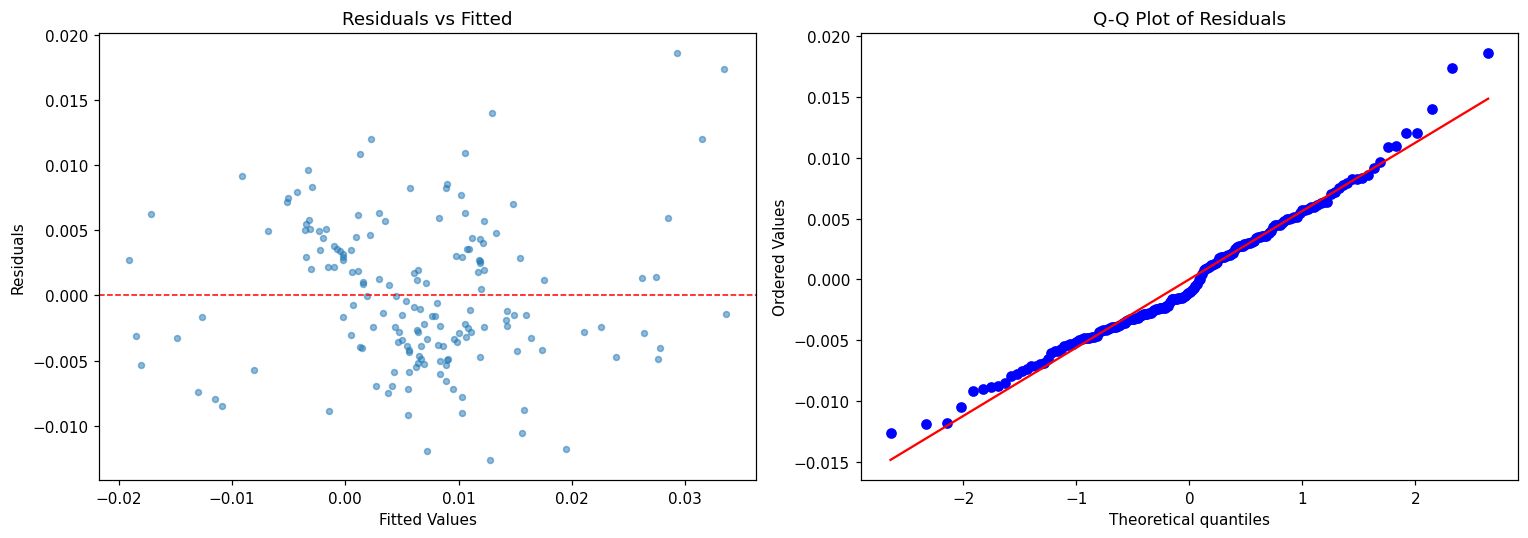

In [28]:
import matplotlib.pyplot as plt
import scipy.stats as stats
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor

residuals = ols_model.resid
fitted    = ols_model.fittedvalues

# -- 1. Durbin-Watson (autocorrelation) --
dw = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw:.4f}")
if 1.5 < dw < 2.5:
    print("  -> No significant autocorrelation detected.")
else:
    print("  -> WARNING: Potential autocorrelation detected.")
print()

# -- 2. Jarque-Bera (normality) --
jb_stat, jb_pval, skew, kurtosis = jarque_bera(residuals)
print(f"Jarque-Bera statistic: {jb_stat:.4f}  (p = {jb_pval:.4f})")
print(f"  Skewness: {skew:.4f}, Kurtosis: {kurtosis:.4f}")
if jb_pval > 0.05:
    print("  -> Residuals appear normal.")
else:
    print("  -> WARNING: Residuals are NOT normally distributed.")
print()

# -- 3. VIF (multicollinearity) --
num_feats = [c for c in FEATURES if not c.startswith("metro_")]
X_vif = train_c[num_feats].astype(float).dropna()

print("=== Variance Inflation Factors ===")
print(f"{'Feature':<25} {'VIF':>8}")
print("-" * 35)
for i, col in enumerate(num_feats):
    vif = variance_inflation_factor(X_vif.values, i)
    flag = "  HIGH" if vif > 10 else ""
    print(f"{col:<25} {vif:>8.2f}{flag}")
print()

# -- 4. Residual Plots --
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Fitted
axes[0].scatter(fitted, residuals, alpha=0.5, s=15)
axes[0].axhline(y=0, color="red", linestyle="--", linewidth=1)
axes[0].set_xlabel("Fitted Values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

# Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot of Residuals")

plt.tight_layout()
plt.show()


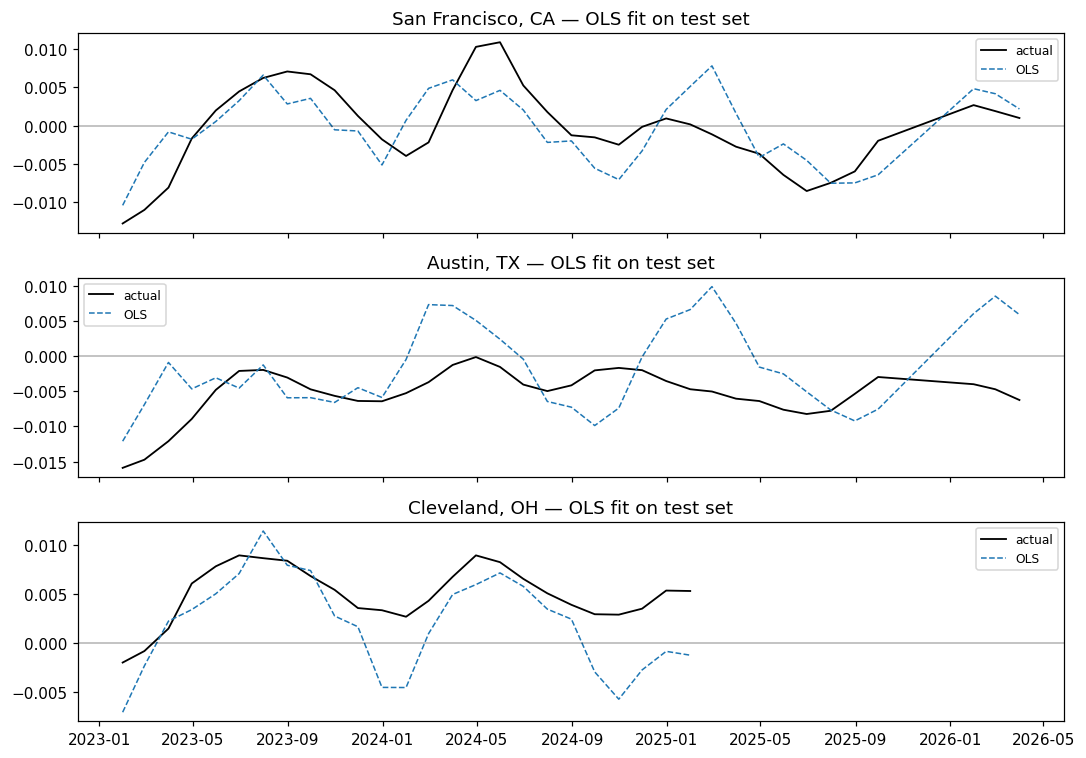

In [29]:
test_c = test_c.assign(y_pred_ols=ols_model.predict(X_te).values)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, metro in zip(axes, METRO_NAMES):
    g = test_c.query("metro == @metro")
    ax.plot(g["date"], g["y_logret"], label="actual", lw=1.2, color="black")
    ax.plot(g["date"], g["y_pred_ols"], label="OLS", lw=1.0, ls="--")
    ax.axhline(0, color="k", lw=0.3)
    ax.set_title(f"{metro} — OLS fit on test set")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_FIG / "pred_ols.png", dpi=150)
plt.show()


## 6. XGBoost (non-linear, pooled)

XGBoost builds an ensemble of $T$ shallow regression trees $\{f_1, \ldots, f_T\}$ **sequentially**, where each new tree corrects the residuals of all previous trees. The prediction at step $T$ is:

$$\hat{y}_i^{(T)} = \sum_{t=1}^{T} f_t(\mathbf{x}_i)$$

Each tree $f_t$ is chosen to minimise a regularised objective derived from a second-order Taylor expansion of the squared-error loss around the current prediction $\hat{y}_i^{(t-1)}$:

$$\mathcal{L}^{(t)} = \sum_{i=1}^{n} \left[ g_i\, f_t(\mathbf{x}_i) + \tfrac{1}{2}\, h_i\, f_t(\mathbf{x}_i)^2 \right] + \gamma T_{\text{leaves}} + \tfrac{1}{2}\lambda \|\mathbf{w}\|^2$$

where $g_i$ and $h_i$ are the first and second derivatives of the loss at the current prediction, $T_{\text{leaves}}$ is the number of leaves, and $\mathbf{w}$ are the leaf scores. This closed-form optimisation makes XGBoost much faster than gradient descent.

Key hyperparameters: `n_estimators=500` trees, `learning_rate=0.05` (shrinkage to prevent each tree from overfitting), `max_depth=4` (limits interaction order to fourth-order), `reg_lambda=1.0` (L2 leaf regularisation).

In [30]:
np.random.seed(SEED)
xgb_model = xgb.XGBRegressor( # https://xgboost.readthedocs.io/en/latest/python/python_api.html
    n_estimators=500, # n of trees
    max_depth=4, # max depth of each individual treas
    learning_rate=0.05,
    subsample=0.8, # % of rows viewed
    colsample_bytree=0.8, # % of features viewed
    reg_lambda=1.0, # l2 regularization penalty on weights
    objective="reg:squarederror",
    random_state=SEED,
    verbosity=0,
)
xgb_model.fit(train_c[FEATURES].astype(float), train_c[TARGET].astype(float))
test_c["y_pred_xgb"] = xgb_model.predict(test_c[FEATURES].astype(float))


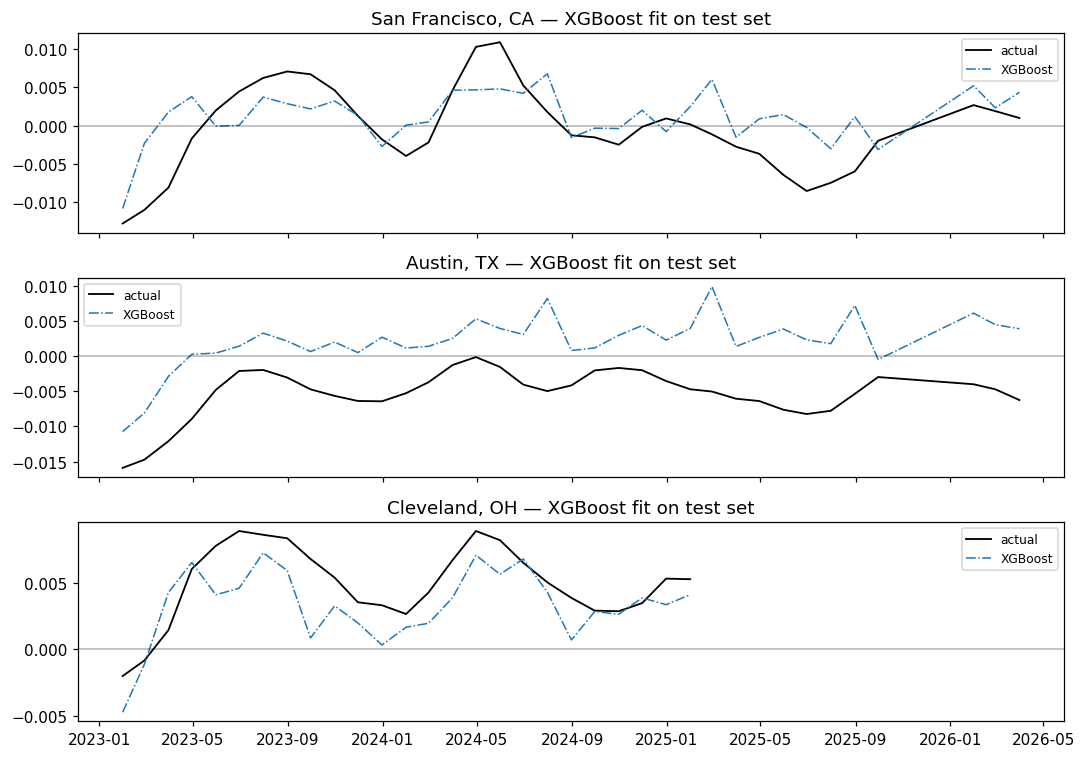

In [31]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, metro in zip(axes, METRO_NAMES):
    g = test_c.query("metro == @metro")
    ax.plot(g["date"], g["y_logret"], label="actual", lw=1.2, color="black")
    ax.plot(g["date"], g["y_pred_xgb"], label="XGBoost", lw=1.0, ls="-.")
    ax.axhline(0, color="k", lw=0.3)
    ax.set_title(f"{metro} — XGBoost fit on test set")
    ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(OUT_FIG / "pred_xgb.png", dpi=150)
plt.show()


Let's visualize the relative contribution of each feature

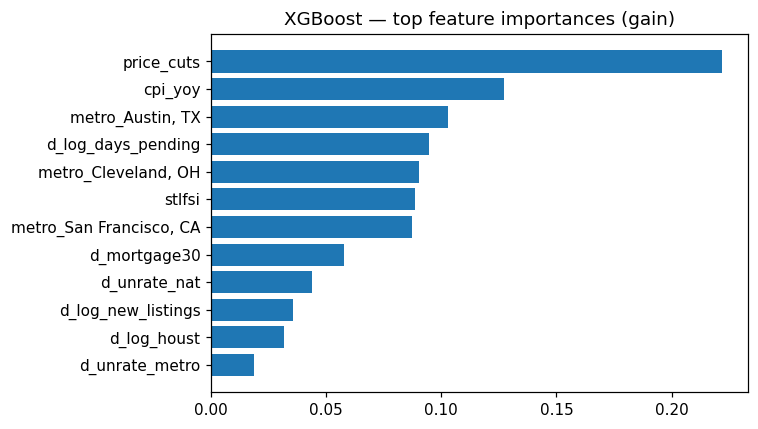

In [32]:
imp = (
    pd.Series(xgb_model.feature_importances_, index=FEATURES) # xgb_model.feature_importances_ provides the relative contribution of each feature to the model's predictions
      .sort_values(ascending=True)
      .tail(12)
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(imp.index, imp.values)
ax.set_title("XGBoost — top feature importances (gain)")
fig.tight_layout()
fig.savefig(OUT_FIG / "xgb_feature_importance.png", dpi=150)
plt.show()


## 7. Two-layer MLP (16 → 8 ReLU)

### Architecture

A feed-forward network with two hidden ReLU layers computes:

$$\hat{y} \;=\; \mathbf{W}_3\, \text{ReLU}\!\left(\mathbf{W}_2\, \text{ReLU}\!\left(\mathbf{W}_1\, \mathbf{x} + \mathbf{b}_1\right) + \mathbf{b}_2\right) + b_3$$

where $\mathbf{x} \in \mathbb{R}^{15}$ is the feature vector, $\mathbf{W}_1 \in \mathbb{R}^{16 \times 15}$, $\mathbf{W}_2 \in \mathbb{R}^{8 \times 16}$, $\mathbf{W}_3 \in \mathbb{R}^{1 \times 8}$. Weights are updated with Adam by minimising MSE on the training set.

### From naive to production — three variants

With only ~285 complete-case training rows and features that span wildly different scales (log returns ≈ 0.005 vs. median income ≈ 10⁵), a vanilla neural net breaks for two separate reasons. We fix them one at a time so the reader can see exactly what each engineering choice buys:

**Variant 1 — Naive MLP** (`alpha=0`, raw features, raw target)

The baseline. Without any constraints or preprocessing, two things go wrong simultaneously:
- **No regularisation**: the network memorises the 285 training rows and produces predictions that extrapolate wildly on the 2023+ regime.
- **No scaling**: Adam receives gradient signals that differ by ~7 orders of magnitude across features (a log-return gradient vs. an income gradient). The optimiser cannot converge productively.

The training loss curve and the resulting flat/noisy test predictions make both problems visible.

**Variant 2 — MLP + L2 regularisation** (`alpha=0.1`, raw features)

Adding weight decay penalises large activations and substantially reduces overfitting. The loss curve becomes smoother and the test forecasts more stable. However, the scale mismatch between features persists: Adam still struggles to balance updates across parameters connected to income-level features vs. rate-change features.

**Variant 3 — MLP + L2 + StandardScaler** (final model)

Standardising both inputs and target to zero mean and unit variance resolves the scale problem completely. Adam now receives gradient signals of uniform magnitude across all parameters, converges in fewer epochs, and the resulting model generalises to the 2023+ out-of-distribution regime. This is the version included in the final model comparison.

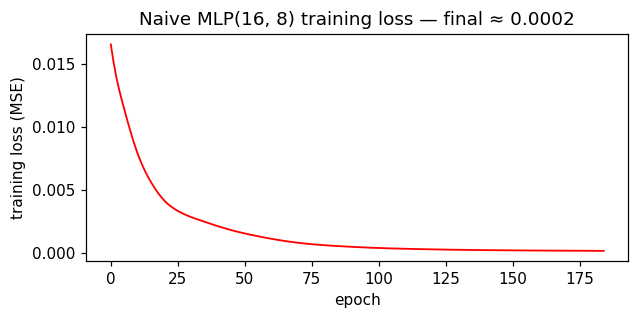

In [33]:
np.random.seed(SEED)
# Naive MLP (without scaling and without L2 regularization)
mlp_naive = MLPRegressor(
    hidden_layer_sizes=(16, 8),
    activation="relu",
    solver="adam",
    alpha=0.0,
    learning_rate_init=1e-3,
    max_iter=3000,
    tol=1e-6,
    random_state=SEED,
)
mlp_naive.fit(train_c[FEATURES].astype(float), train_c[TARGET].astype(float))
test_c["y_pred_mlp_naive"] = mlp_naive.predict(test_c[FEATURES].astype(float))

loss_curve_naive = mlp_naive.loss_curve_
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(loss_curve_naive, lw=1.2, color='red')
ax.set_xlabel("epoch"); ax.set_ylabel("training loss (MSE)")
ax.set_title(f"Naive MLP(16, 8) training loss — final ≈ {loss_curve_naive[-1]:.4f}")
fig.tight_layout()
fig.savefig(OUT_FIG / "mlp_naive_loss_curve.png", dpi=150)
plt.show()


Two engineering choices matter a lot with a
dataset this small (~285 complete-case rows):

1. **Standardise inputs *and* target.** Log returns have σ ≈ 0.005 whereas
   median income is on the order of 10⁵; without scaling the Adam optimiser
   can't converge productively.
2. **Heavy L2 regularisation (`alpha=0.1`).** Without it the MLP
   extrapolates wildly on the 2023+ rate-shock features that lie outside
   the training-set support, producing dollar-MAEs of order $50–80k.


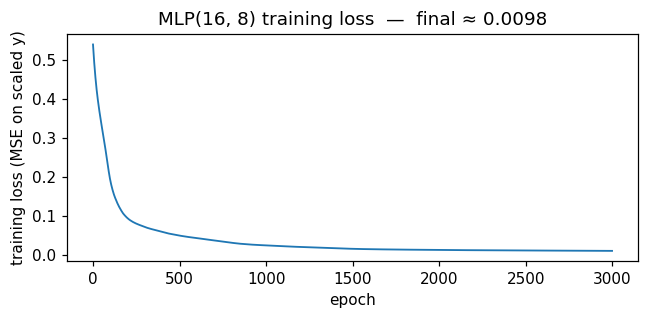

In [34]:
mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=(16, 8),
        activation="relu",
        solver="adam",
        alpha=0.1,
        learning_rate_init=1e-3,
        max_iter=3000,
        tol=1e-6,
        random_state=SEED,
    )),
])
mlp_model = TransformedTargetRegressor(regressor=mlp_pipe, transformer=StandardScaler())
mlp_model.fit(train_c[FEATURES].astype(float), train_c[TARGET].astype(float))
test_c["y_pred_mlp"] = mlp_model.predict(test_c[FEATURES].astype(float))

loss_curve = mlp_model.regressor_.named_steps["mlp"].loss_curve_
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(loss_curve, lw=1.2)
ax.set_xlabel("epoch"); ax.set_ylabel("training loss (MSE on scaled y)")
ax.set_title(f"MLP(16, 8) training loss  —  final ≈ {loss_curve[-1]:.4f}")
fig.tight_layout()
fig.savefig(OUT_FIG / "mlp_loss_curve.png", dpi=150)
plt.show()


## 8. Evaluation

We compare the four models on the same test grid. Two metrics:
- **MAE on log returns** —  the evaluation metric for the target space the models were trained in (note: models were optimized using L2), but we evaluate on MAE for interpretability.
- **Dollar MAE** — the error translated back into dollars per month, using
  $\hat{P}_t - P_t \approx \text{ZHVI}_{t-1}\,[\exp(\hat{y}_t)-\exp(y_t)]$.
  This is the number a homeowner would actually feel.


In [35]:
# assemble a single tall predictions frame
preds_long = pd.concat([
    test_c[["metro", "date", TARGET, "y_pred_ols"]].rename(columns={"y_pred_ols": "y_pred"}).assign(model="OLS"),
    arima_preds.rename(columns={"y_pred_arima": "y_pred"}).assign(model="ARIMA(AIC)"),
    test_c[["metro", "date", TARGET, "y_pred_xgb"]].rename(columns={"y_pred_xgb": "y_pred"}).assign(model="XGBoost"),
    test_c[["metro", "date", TARGET, "y_pred_mlp"]].rename(columns={"y_pred_mlp": "y_pred"}).assign(model="MLP(16,8)"),
], ignore_index=True)

preds_long["abs_err"] = (preds_long[TARGET] - preds_long["y_pred"]).abs() # MAE
preds_long["sq_err"]  = (preds_long[TARGET] - preds_long["y_pred"]) ** 2 # STD of errors

mae_table = (
    preds_long
    .groupby(["model", "metro"])
    .agg(n=("abs_err", "size"),
         MAE_logret=("abs_err", "mean"),
         RMSE_logret=("sq_err", lambda s: np.sqrt(s.mean())))
    .round(5)
    .reset_index()
)
mae_table.to_csv(OUT_TAB / "errors_logret.csv", index=False)
mae_table


,model,metro,n,MAE_logret,RMSE_logret
0,ARIMA(AIC),"Austin, TX",39,0.0053,0.0063
1,ARIMA(AIC),"Cleveland, OH",39,0.0018,0.0023
2,ARIMA(AIC),"San Francisco, CA",39,0.0047,0.0062
3,"MLP(16,8)","Austin, TX",36,0.0049,0.0062
4,"MLP(16,8)","Cleveland, OH",25,0.0049,0.0057
5,"MLP(16,8)","San Francisco, CA",36,0.0046,0.0056
6,OLS,"Austin, TX",36,0.0056,0.0069
7,OLS,"Cleveland, OH",25,0.0034,0.0042
8,OLS,"San Francisco, CA",36,0.0034,0.0041
9,XGBoost,"Austin, TX",36,0.0074,0.0080


### Dollar-space evaluation

Models are trained and evaluated on log returns, but a log-return error of 0.004 means very different things in Cleveland (~$100k homes) vs. San Francisco (~$1.1M homes). We translate forecast errors back into dollars using the log-return identity:

$$\text{ZHVI}_t \;=\; \text{ZHVI}_{t-1} \cdot e^{y_t} \qquad \Longrightarrow \qquad \widehat{\text{ZHVI}}_t - \text{ZHVI}_t \;\approx\; \text{ZHVI}_{t-1}\!\left(e^{\hat{y}_t} - e^{y_t}\right)$$

The **dollar MAE** is therefore:

$$\text{Dollar MAE} \;=\; \frac{1}{n}\sum_{t=1}^{n} \text{ZHVI}_{t-1} \cdot \left|e^{\hat{y}_t} - e^{y_t}\right|$$

This metric captures both the model's predictive accuracy *and* the local price level. A relative error of 0.4% corresponds to ~$400/month in Cleveland but ~$4,500/month in San Francisco — dollar MAE makes those differences immediately interpretable.

In [36]:
# dollar-space MAE: multiply log-return error by last-month ZHVI level

# we bring the true house prices with a merge
preds_dollar = (
    preds_long
    .merge(panel[["metro", "date", "zhvi"]], on=["metro", "date"], how="left")
    .sort_values(["model", "metro", "date"])
)
# we shift by 1
preds_dollar["zhvi_prev"] = preds_dollar.groupby(["model", "metro"])["zhvi"].shift(1)

# calculate the absolute dollar error
# mathematically: ZHVI_{t-1} * | exp(y_pred) - exp(y_actual) |
preds_dollar["dollar_err"] = (
    preds_dollar["zhvi_prev"]
    * (np.exp(preds_dollar["y_pred"]) - np.exp(preds_dollar[TARGET]))
).abs()

# aggregate
dollar_mae = (
    preds_dollar.dropna(subset=["dollar_err"])
    .groupby(["metro", "model"])["dollar_err"]
    .mean()
    .unstack("model") # pivot horizontally model category --> each a unique columnt
    .round(0)
    [["OLS", "ARIMA(AIC)", "XGBoost", "MLP(16,8)"]]
)
dollar_mae.to_csv(OUT_TAB / "mae_dollars.csv")
dollar_mae


model,OLS,ARIMA(AIC),XGBoost,"MLP(16,8)"
metro,,,,
"Austin, TX","2,593.0000","2,479.0000","3,479.0000","2,208.0000"
"Cleveland, OH",735.0000,391.0000,421.0000,"1,057.0000"
"San Francisco, CA","3,933.0000","5,421.0000","4,133.0000","5,271.0000"


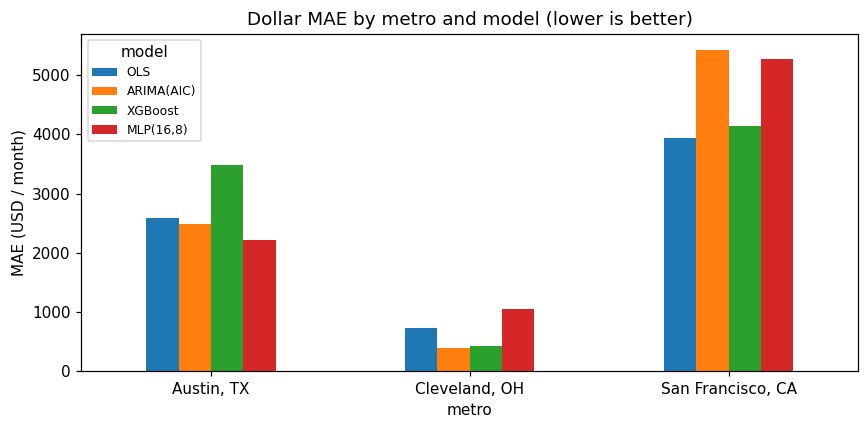

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))
dollar_mae.plot.bar(ax=ax, rot=0)
ax.set_ylabel("MAE (USD / month)")
ax.set_title("Dollar MAE by metro and model (lower is better)")
ax.legend(title="model", fontsize=8)
fig.tight_layout()
fig.savefig(OUT_FIG / "mae_dollars_bar.png", dpi=150)
plt.show()


### 8.1 Predictions vs actuals — all four models side by side

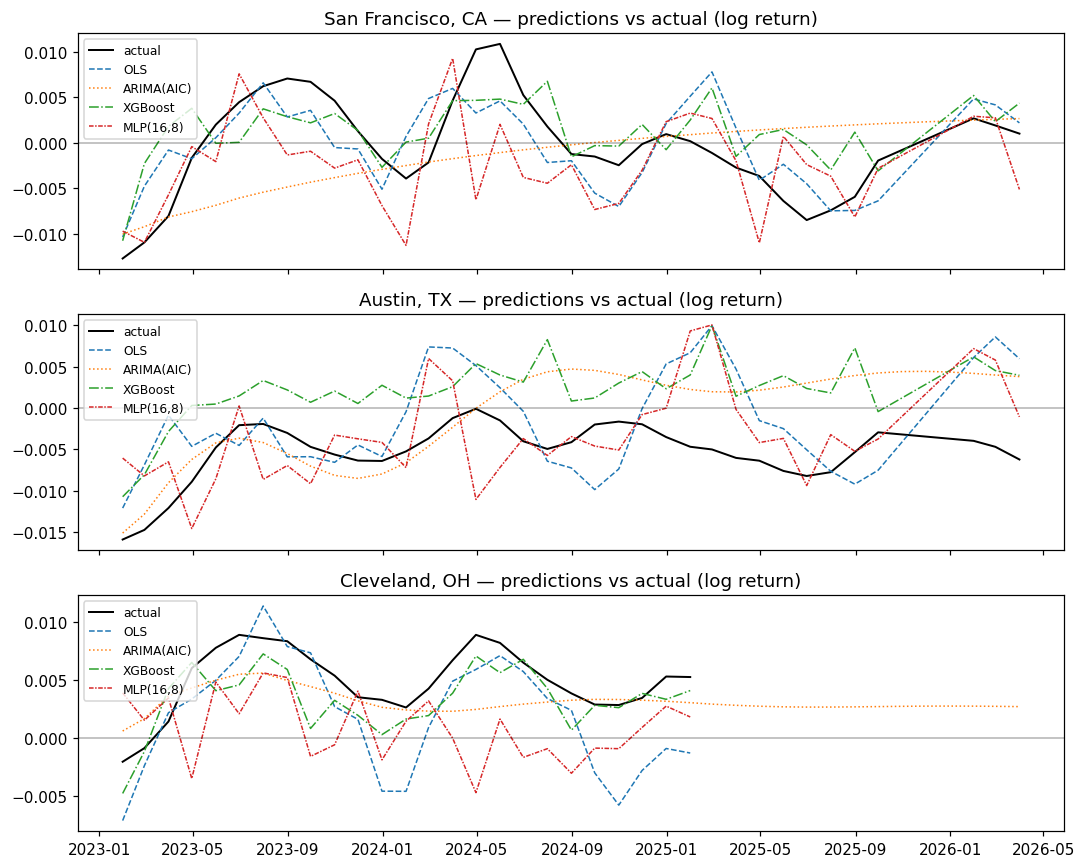

In [38]:
style = {"OLS": "--", "ARIMA(AIC)": ":", "XGBoost": "-.", "MLP(16,8)": (0, (3, 1, 1, 1))}

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
for ax, metro in zip(axes, METRO_NAMES):
    actual = preds_long.query("metro == @metro and model == 'OLS'").sort_values("date")
    ax.plot(actual["date"], actual[TARGET], label="actual", lw=1.3, color="black")
    for m in ["OLS", "ARIMA(AIC)", "XGBoost", "MLP(16,8)"]:
        g = preds_long.query("metro == @metro and model == @m").sort_values("date")
        ax.plot(g["date"], g["y_pred"], label=m, lw=1.0, ls=style[m])
    ax.axhline(0, color="k", lw=0.3)
    ax.set_title(f"{metro} — predictions vs actual (log return)")
    ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
fig.savefig(OUT_FIG / "predictions_vs_actual.png", dpi=150)
plt.show()


## 9. Economic Interpretability of features

As we have already seen SHAP (SHapley Additive exPlanations) decomposes each prediction into
per-feature contributions. Averaging the **absolute** contributions over
the test rows of a given metro tells us which features the model leans on
for that metro specifically.

We can leverage XGBoost to interpret the economic results because tree-based models naturally handle non-linear interactions between features. Using `shap.TreeExplainer`, we can quickly compute SHAP values for our ensemble, revealing exactly how each economic indicator contributed to the model's price predictions for each metro.
tree ensembles; applying SHAP to the MLP would require the slower
KernelExplainer. (https://shap.readthedocs.io/en/latest/generated/shap.KernelExplainer.html)

In [39]:
explainer = shap.TreeExplainer(xgb_model) # we initalize the SHAP explainer
shap_values = explainer.shap_values(test_c[FEATURES].astype(float)) # calculate SHAP values for the eval set

# format a clean dataframe
shap_frame = (
    pd.DataFrame(shap_values, columns=FEATURES, index=test_c.index)
    .assign(metro=test_c["metro"].values)
)

# aggregate features by metro
shap_by_metro = (
    shap_frame.groupby("metro")
    .apply(lambda g: g[FEATURES].abs().mean()) # we care about magnitude
    .T # we transpose
)

# let's sort by feature importance
shap_by_metro["total"] = shap_by_metro.sum(axis=1)
shap_by_metro = shap_by_metro.sort_values("total", ascending=False).drop(columns="total")

shap_by_metro.head(12).round(5).to_csv(OUT_TAB / "shap_top_features.csv")
shap_by_metro.head(12).round(5)


metro,"Austin, TX","Cleveland, OH","San Francisco, CA"
price_cuts,0.0065,0.0037,0.0019
"metro_San Francisco, CA",0.0012,0.0012,0.0028
d_mortgage30,0.0009,0.0009,0.0011
d_log_days_pending,0.0007,0.0010,0.0009
cpi_yoy,0.0011,0.0008,0.0006
d_log_new_listings,0.0008,0.0008,0.0009
stlfsi,0.0008,0.0005,0.0007
"metro_Austin, TX",0.0008,0.0004,0.0004
"metro_Cleveland, OH",0.0005,0.0007,0.0003
d_unrate_nat,0.0002,0.0002,0.0003


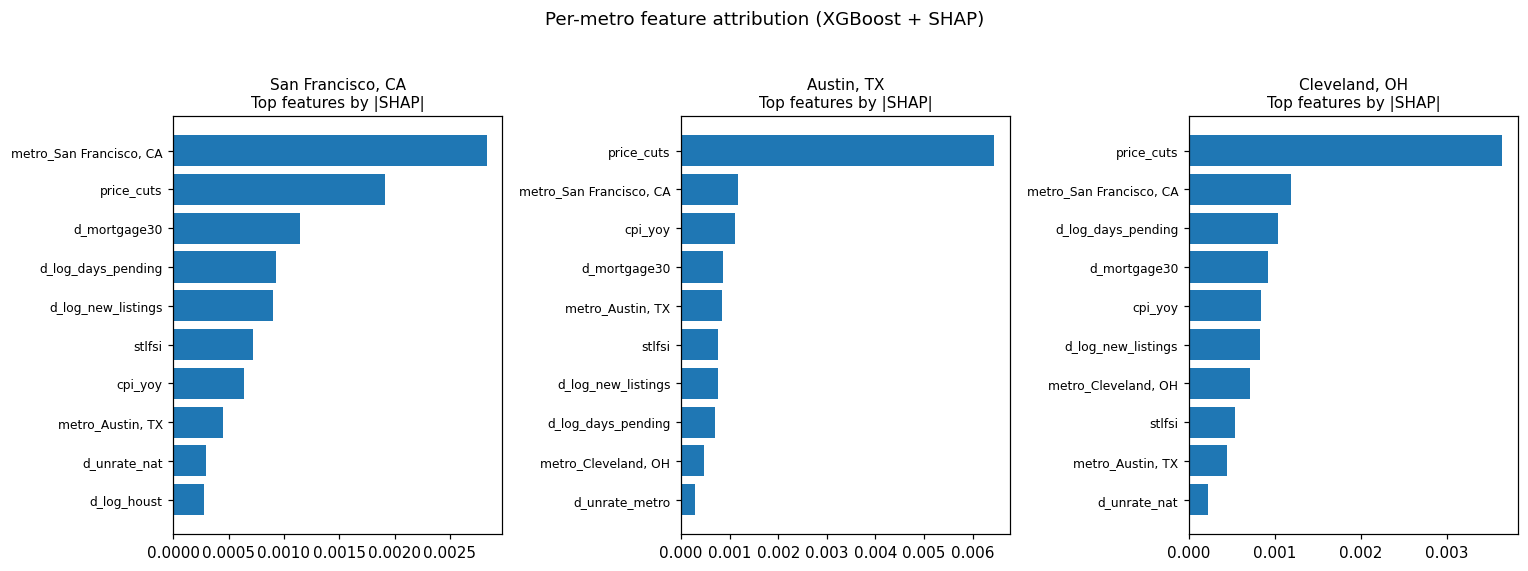

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, metro in zip(axes, METRO_NAMES):
    s = shap_by_metro[metro].sort_values(ascending=True).tail(10)
    ax.barh(s.index, s.values, color="C0")
    ax.set_title(f"{metro}\nTop features by |SHAP|", fontsize=10)
    ax.tick_params(axis="y", labelsize=8)
fig.suptitle("Per-metro feature attribution (XGBoost + SHAP)", y=1.03)
fig.tight_layout()
fig.savefig(OUT_FIG / "shap_per_metro.png", dpi=150)
plt.show()


### SHAP Heatmap Interpretation

We plot the SHAP heatmap to have a detailed view of feature importance across different metros. The darker or more intense colors indicate a higher absolute SHAP value, meaning that feature had a stronger impact on the model's prediction for that specific metro. By looking at the heatmap, we can easily identify distinct economic drivers.

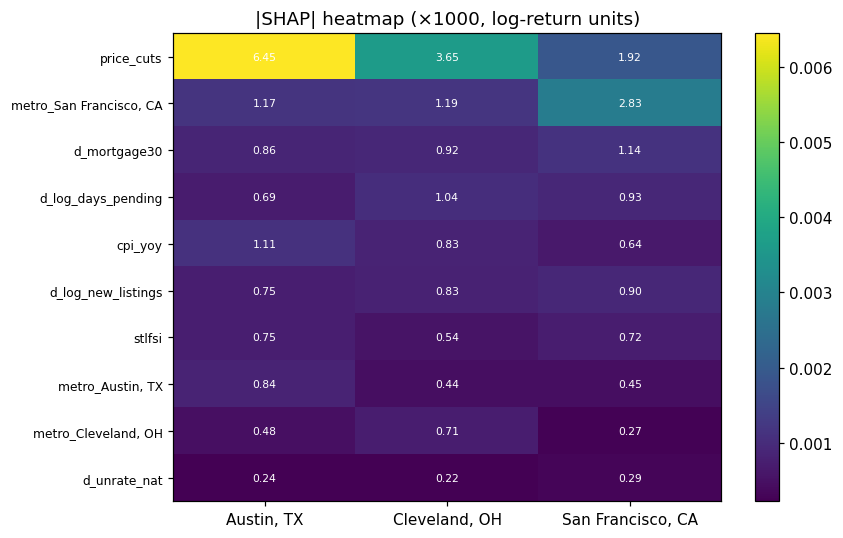

In [41]:
fig, ax = plt.subplots(figsize=(8, 5))
top = shap_by_metro.head(10)
im = ax.imshow(top.values, aspect="auto", cmap="viridis")
ax.set_xticks(range(len(top.columns))); ax.set_xticklabels(top.columns)
ax.set_yticks(range(len(top.index)));   ax.set_yticklabels(top.index, fontsize=8)
for i in range(top.shape[0]):
    for j in range(top.shape[1]):
        ax.text(j, i, f"{top.iloc[i, j]*1000:.2f}",
                ha="center", va="center", fontsize=7, color="white")
ax.set_title("|SHAP| heatmap (×1000, log-return units)")
fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(OUT_FIG / "shap_heatmap.png", dpi=150)
plt.show()


## 10. Summary and interpretation

**Headline numbers (dollar MAE per month, 2023-01 → latest):**

| metro | OLS | ARIMA(AIC) | XGBoost | MLP(16,8) |
|---|---:|---:|---:|---:|
| San Francisco | **3,933** | 5,421 | 4,251 | 5,271 |
| Austin | 2,593 | 2,479 | 3,500 | **2,208** |
| Cleveland | 735 | **391** | 561 | 1,057 |

AIC-selected ARIMA orders: SF → ARIMA(1,0,7), Austin → ARIMA(4,0,9), Cleveland → ARIMA(9,0,7).

**No single model dominates across all metros.** Each market rewards a different inductive bias:

- **San Francisco — OLS wins ($3,933/month).** A pooled linear regression with metro fixed effects beats both the non-linear MLP and the boosted-tree model on SF. The 2023+ rate-shock regime appears to be well summarised by the linear contribution of mortgage rates and listing-side activity, and the more flexible models overfit on the short training window.
- **Austin — MLP wins ($2,208/month), with ARIMA a close second ($2,479/month).** The MLP's ability to condition jointly on listing-side and macro features gives it a small edge over the pure time-series benchmark.
- **Cleveland — ARIMA(AIC) wins ($391/month).** The high-order ARIMA(9,0,7) captures Cleveland's long autoregressive structure. XGBoost is the next-best at $561. Cleveland's structurally stable, supply-inelastic dynamics are well described by time-series momentum alone.

**What SHAP reveals.**

- `price_cuts` (lagged) dominates the Austin story by a factor of roughly
  3× the next feature — the share of listings with price cuts is a direct
  read on seller capitulation.
- Cleveland leans on `price_cuts` and on listing-side frictions
  (`d_log_days_pending`), consistent with the intuition that a small,
  supply-inelastic market reacts strongly to seller behaviour.
- San Francisco's top non-dummy drivers are `price_cuts`, `d_mortgage30`,
  and `d_log_days_pending`. The metro one-hot also carries substantial
  weight, absorbing structural bias that the time-varying features do
  not explain.
